# 9. Comparative Comment Matching Analysis

Comment-level coverage, groundedness, and metric-validation summaries.


## 9.1 Setup and Data Loading

Load matching artifacts and prepare shared analysis tables.


### 9.1.1 Imports, Paths, and Analysis Configuration

Configure project paths, model labels, and output folders.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "code").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root()
CODE_DIR = PROJECT_ROOT / "code"
RESULTS_DIR = CODE_DIR / "results" / "critiques"
MATCHING_DIR = RESULTS_DIR / "matching"
TABLES_DIR = RESULTS_DIR / "analysis" / "tables"
FIGURES_DIR = RESULTS_DIR / "analysis" / "figures"

for directory in [TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))

from utils.screen_display import show_screen

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

RUN_LABEL = "zero_shot-all_tasks"
MODEL_ORDER = ["claude4_7", "gpt5", "gemini3_1pro"]
MODEL_DISPLAY = {
    "gpt5": "GPT-5",
    "claude4_7": "Claude Opus 4.7",
    "gemini3_1pro": "Gemini 3.1 Pro",
    "qwen3_vl": "Qwen3-VL",
}

PAIR_KEYS = ["model_short", "screen_task_id", "expert_comment_id", "llm_comment_id"]
MODEL_GROUP_COLS = ["model_short", "model_name"]
COMMENT_GROUP_BASE = [*MODEL_GROUP_COLS, "screen_task_id"]
EXPERT_GROUP_COLS = [*COMMENT_GROUP_BASE, "expert_comment_id"]
LLM_GROUP_COLS = [*COMMENT_GROUP_BASE, "llm_comment_id"]


def presentation_df(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=["model_short"], errors="ignore")


def display_df(df: pd.DataFrame) -> None:
    display(presentation_df(df))

RELATION_CONFIG = [
    {"relation": "equivalent", "coverage": "Fully covered", "groundedness": "Strongly grounded"},
    {"relation": "B_broader", "coverage": "Fully covered", "groundedness": "Weakly grounded"},
    {"relation": "A_broader", "coverage": "Partially covered", "groundedness": "Strongly grounded"},
    {"relation": "partial_overlap", "coverage": "Partially covered", "groundedness": "Weakly grounded"},
    {"relation": "contradiction", "coverage": "Contradiction", "groundedness": "Contradiction"},
    {"relation": "related_but_different", "coverage": "Not covered", "groundedness": "Unsupported/extra"},
    {"relation": "no_match", "coverage": "Not covered", "groundedness": "Unsupported/extra"},
]
RELATION_ORDER = [item["relation"] for item in RELATION_CONFIG]
RELATION_RANK = {relation: rank for rank, relation in enumerate(RELATION_ORDER)}
VALID_RELATIONS = set(RELATION_ORDER)

CATEGORY_CONFIG = {
    "coverage": {
        "relation_map": {item["relation"]: item["coverage"] for item in RELATION_CONFIG},
        "order": ["Fully covered", "Partially covered", "Contradiction", "Not covered"],
        "default": "Not covered",
        "colors": {
            "Fully covered": "#3DB143",
            "Partially covered": "#F4BB59",
            "Contradiction": "#F06868",
            "Not covered": "#9B7CFF",
        },
    },
    "groundedness": {
        "relation_map": {item["relation"]: item["groundedness"] for item in RELATION_CONFIG},
        "order": ["Strongly grounded", "Weakly grounded", "Contradiction", "Unsupported/extra"],
        "default": "Unsupported/extra",
        "colors": {
            "Strongly grounded": "#3DB143",
            "Weakly grounded": "#F4BB59",
            "Contradiction": "#F06868",
            "Unsupported/extra": "#9B7CFF",
        },
    },
}

print("Project root:", PROJECT_ROOT)
print("Run label:", RUN_LABEL)
print("Models:", MODEL_ORDER)


Project root: /home/mkhalil/thesis/Project
Run label: zero_shot-all_tasks
Models: ['claude4_7', 'gpt5', 'gemini3_1pro']


### 9.1.2 Load Per-Model Matching Artifacts

Load and combine completed matching artifacts for each model.


In [2]:
ARTIFACTS = {
    "all_pairs": "all_comment_pairs-{stem}.parquet",
    "lexical": "lexical_pairs-{stem}.parquet",
    "semantic": "semantic_pairs-{stem}.parquet",
    "bertscore": "bertscore_pairs-{stem}.parquet",
    "nli": "nli_pairs-{stem}.parquet",
    "pair_labels": "llmjudge_matching/llmjudge_matching_pairs-{stem}.parquet",
}


def artifact_path(model: str, artifact: str) -> Path:
    stem = f"{RUN_LABEL}-{model}"
    return MATCHING_DIR / model / RUN_LABEL / ARTIFACTS[artifact].format(stem=stem)


def load_artifact(model: str, artifact: str) -> pd.DataFrame:
    path = artifact_path(model, artifact)
    df = pd.read_parquet(path).copy()
    df["model_short"] = model
    df["model_name"] = MODEL_DISPLAY.get(model, model)
    return df


def load_all(artifact: str) -> pd.DataFrame:
    return pd.concat([load_artifact(model, artifact) for model in MODEL_ORDER], ignore_index=True)


all_pairs_df = load_all("all_pairs")
pair_labels_df = load_all("pair_labels")
metric_artifacts = {name: load_all(name) for name in ["lexical", "semantic", "bertscore", "nli"]}

if "llm_guideline_reference" not in all_pairs_df.columns and "llm_guideline_reference" in metric_artifacts["lexical"].columns:
    lexical_guidelines_df = metric_artifacts["lexical"][[*PAIR_KEYS, "llm_guideline_reference"]].drop_duplicates(PAIR_KEYS)
    all_pairs_df = all_pairs_df.merge(
        lexical_guidelines_df,
        on=PAIR_KEYS,
        how="left",
        validate="one_to_one",
    )

load_summary_df = pd.DataFrame([
    {"model": MODEL_DISPLAY.get(model, model), "artifact": artifact, "rows": len(load_artifact(model, artifact))}
    for model in MODEL_ORDER
    for artifact in ARTIFACTS
])

display_df(load_summary_df)


,model,artifact,rows
0,Claude Opus 4.7,all_pairs,72285
1,Claude Opus 4.7,lexical,72285
2,Claude Opus 4.7,semantic,72285
3,Claude Opus 4.7,bertscore,72285
4,Claude Opus 4.7,nli,72285
5,Claude Opus 4.7,pair_labels,72285
6,GPT-5,all_pairs,64255
7,GPT-5,lexical,64255
8,GPT-5,semantic,64255
9,GPT-5,bertscore,64255


Two tasks, _20234_T03_ and _31563_T02_, were excluded from cross-model matching analyses because GPT-5 returned an empty critique list for them, producing no candidate pairs for LLM-judge matching. The final comparison uses the 2,950 tasks shared by all three models.

In [3]:
EXCLUDED_SCREEN_TASK_IDS = {
    "20234_T03",
    "31563_T02",
}

def drop_excluded_tasks(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if "screen_task_id" not in df.columns:
        return df

    before = len(df)
    out = df[~df["screen_task_id"].isin(EXCLUDED_SCREEN_TASK_IDS)].copy()
    dropped = before - len(out)

    print(f"{name}: dropped {dropped:,} rows from excluded tasks")
    return out


all_pairs_df = drop_excluded_tasks(all_pairs_df, "all_pairs_df")
pair_labels_df = drop_excluded_tasks(pair_labels_df, "pair_labels_df")

metric_artifacts = {
    name: drop_excluded_tasks(df, name)
    for name, df in metric_artifacts.items()
}

all_pairs_df: dropped 35 rows from excluded tasks
pair_labels_df: dropped 35 rows from excluded tasks
lexical: dropped 35 rows from excluded tasks
semantic: dropped 35 rows from excluded tasks
bertscore: dropped 35 rows from excluded tasks
nli: dropped 35 rows from excluded tasks


### 9.1.3 Standardize and Validate Identifiers

Standardize identifiers and validate required matching fields.


In [4]:
for name, df, required in [
    ("all_pairs_df", all_pairs_df, ["pair_id", *PAIR_KEYS]),
    ("pair_labels_df", pair_labels_df, ["pair_id", *PAIR_KEYS, "relation", "confidence"]),
]:
    missing = sorted(set(required) - set(df.columns))
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

invalid_relations = sorted(set(pair_labels_df["relation"].dropna()) - VALID_RELATIONS)
if invalid_relations:
    raise ValueError(f"Invalid relation labels: {invalid_relations}")

reference_tasks = set(all_pairs_df.loc[all_pairs_df["model_short"].eq(MODEL_ORDER[0]), "screen_task_id"])
for model in MODEL_ORDER:
    model_pairs = all_pairs_df[all_pairs_df["model_short"].eq(model)]
    model_labels = pair_labels_df[pair_labels_df["model_short"].eq(model)]
    if set(model_pairs["screen_task_id"]) != reference_tasks:
        raise ValueError(f"Task set mismatch for {model}.")
    if len(model_pairs) != len(model_labels):
        raise ValueError(f"Pair/label row mismatch for {model}.")
    if model_labels["pair_id"].duplicated().any():
        raise ValueError(f"Duplicate pair_id values for {model}.")

print("Identifier validation passed.")


Identifier validation passed.


#### Validate NaN


In [5]:
nan_check_artifacts = {
    "lexical": metric_artifacts["lexical"],
    "bertscore": metric_artifacts["bertscore"],
    "semantic": metric_artifacts["semantic"],
    "nli": metric_artifacts["nli"],
    "llmjudge_matching": pair_labels_df,
}

nan_records = []
nan_records_all = []
seen_nan_columns_by_model = {model_short: set() for model_short in MODEL_ORDER}
for artifact_name, df in nan_check_artifacts.items():
    for model_short, model_df in df.groupby("model_short", sort=False):
        missing_counts = model_df.isna().sum()
        missing_counts = missing_counts[missing_counts.gt(0)]
        for column, missing_count in missing_counts.items():
            record = {
                "artifact": artifact_name,
                "model_short": model_short,
                "model_name": MODEL_DISPLAY.get(model_short, model_short),
                "column": column,
                "missing_rows": int(missing_count),
                "total_rows": int(len(model_df)),
                "missing_pct": round(float(missing_count / len(model_df) * 100), 2),
            }
            nan_records_all.append(record)
            if column in seen_nan_columns_by_model.setdefault(model_short, set()):
                continue
            seen_nan_columns_by_model[model_short].add(column)
            nan_records.append(record)

nan_all_summary_df = pd.DataFrame(nan_records_all)
nan_summary_df = pd.DataFrame(nan_records)

if nan_summary_df.empty:
    print("No NaN values found in lexical, BERTScore, semantic, NLI, or LLMJudge matching artifacts.")
    nan_summary_by_model = {
        model_short: pd.DataFrame(columns=[
            "artifact", "model_short", "model_name", "column", "missing_rows", "total_rows", "missing_pct"
        ])
        for model_short in MODEL_ORDER
    }
else:
    nan_summary_df = nan_summary_df.sort_values(
        ["model_short", "artifact", "missing_rows", "column"],
        ascending=[True, True, False, True],
    ).reset_index(drop=True)

    nan_summary_by_model = {
        model_short: nan_summary_df.loc[nan_summary_df["model_short"].eq(model_short)].reset_index(drop=True)
        for model_short in MODEL_ORDER
    }

    for model_short, model_nan_df in nan_summary_by_model.items():
        print(f"NaN summary for {MODEL_DISPLAY.get(model_short, model_short)}")
        if model_nan_df.empty:
            print("No NaN values found.\n")
        else:
            display_df(model_nan_df)

nan_summary_claude4_7_df = nan_summary_by_model.get("claude4_7", pd.DataFrame())
nan_summary_gpt5_df = nan_summary_by_model.get("gpt5", pd.DataFrame())
nan_summary_gemini3_1pro_df = nan_summary_by_model.get("gemini3_1pro", pd.DataFrame())


NaN summary for Claude Opus 4.7


,artifact,model_name,column,missing_rows,total_rows,missing_pct
0,llmjudge_matching,Claude Opus 4.7,manual_confidence,71852,72258,99.44
1,llmjudge_matching,Claude Opus 4.7,manual_relation,71852,72258,99.44
2,llmjudge_matching,Claude Opus 4.7,comment_b_depends_on_unseen_interaction,16420,72258,22.72
3,llmjudge_matching,Claude Opus 4.7,same_target_element,15650,72258,21.66
4,llmjudge_matching,Claude Opus 4.7,same_usability_problem,7424,72258,10.27
5,llmjudge_matching,Claude Opus 4.7,comment_a_depends_on_unseen_interaction,3780,72258,5.23
6,llmjudge_matching,Claude Opus 4.7,logical_conflict,256,72258,0.35


NaN summary for GPT-5


,artifact,model_name,column,missing_rows,total_rows,missing_pct
0,llmjudge_matching,GPT-5,manual_confidence,64028,64255,99.65
1,llmjudge_matching,GPT-5,manual_relation,64028,64255,99.65
2,llmjudge_matching,GPT-5,same_target_element,14131,64255,21.99
3,llmjudge_matching,GPT-5,comment_b_depends_on_unseen_interaction,12699,64255,19.76
4,llmjudge_matching,GPT-5,same_usability_problem,6935,64255,10.79
5,llmjudge_matching,GPT-5,comment_a_depends_on_unseen_interaction,3300,64255,5.14
6,llmjudge_matching,GPT-5,logical_conflict,200,64255,0.31


NaN summary for Gemini 3.1 Pro


,artifact,model_name,column,missing_rows,total_rows,missing_pct
0,llmjudge_matching,Gemini 3.1 Pro,manual_confidence,35705,36007,99.16
1,llmjudge_matching,Gemini 3.1 Pro,manual_relation,35705,36007,99.16
2,llmjudge_matching,Gemini 3.1 Pro,same_target_element,7713,36007,21.42
3,llmjudge_matching,Gemini 3.1 Pro,same_usability_problem,3977,36007,11.05
4,llmjudge_matching,Gemini 3.1 Pro,comment_b_depends_on_unseen_interaction,3770,36007,10.47
5,llmjudge_matching,Gemini 3.1 Pro,comment_a_depends_on_unseen_interaction,1832,36007,5.09
6,llmjudge_matching,Gemini 3.1 Pro,logical_conflict,134,36007,0.37


### 9.1.4 Merge Metric Columns for Selected Match Rows

Prepare metric columns for selected match validation.


In [6]:
pair_label_columns = [*PAIR_KEYS, "model_name", "pair_id", "relation", "confidence"]
pair_context_columns = [col for col in all_pairs_df.columns if col not in {"pair_id", "model_name"}]
metric_lookup_df = all_pairs_df[[*PAIR_KEYS]].drop_duplicates(PAIR_KEYS)

METRIC_COLUMNS = {
    "lexical": ["jaccard_similarity", "tfidf_cosine_similarity", "bleu", "rouge_l_f1"],
    "semantic": ["cosine_similarity"],
    "bertscore": ["bertscore_precision", "bertscore_recall", "bertscore_f1"],
    "nli": [
        "expert_entails_llm_entailment",
        "expert_entails_llm_contradiction",
        "llm_entails_expert_entailment",
        "llm_entails_expert_contradiction",
    ],
}

for artifact, cols in METRIC_COLUMNS.items():
    df = metric_artifacts[artifact]
    keep_cols = [col for col in cols if col in df.columns]
    metric_lookup_df = metric_lookup_df.merge(
        df[[*PAIR_KEYS, *keep_cols]].drop_duplicates(PAIR_KEYS),
        on=PAIR_KEYS,
        how="left",
        validate="one_to_one",
    )

metric_pairs_df = (
    pair_labels_df[pair_label_columns].drop_duplicates(PAIR_KEYS)
    .merge(
        all_pairs_df[pair_context_columns].drop_duplicates(PAIR_KEYS),
        on=PAIR_KEYS,
        how="left",
        validate="one_to_one",
    )
    .merge(metric_lookup_df, on=PAIR_KEYS, how="left", validate="one_to_one")
)

display_df(metric_pairs_df.head(2))


,screen_task_id,expert_comment_id,llm_comment_id,model_name,pair_id,relation,confidence,app_category,app,screen_id,...,bleu,rouge_l_f1,cosine_similarity,bertscore_precision,bertscore_recall,bertscore_f1,expert_entails_llm_entailment,expert_entails_llm_contradiction,llm_entails_expert_entailment,llm_entails_expert_contradiction
0,10089_T01,10089_T01_002,L_claude4_7_10089_T01_001,Claude Opus 4.7,P_00000001,no_match,0.975,Sports,UNC: Free,10089,...,0.009009,0.088889,0.115955,0.843917,0.850787,0.847338,0.005273,0.846185,0.011778,0.126772
1,10089_T01,10089_T01_002,L_claude4_7_10089_T01_002,Claude Opus 4.7,P_00000002,no_match,0.840,Sports,UNC: Free,10089,...,0.011649,0.125000,0.114425,0.827766,0.845282,0.836433,0.022460,0.045821,0.018628,0.144862


### 9.1.5 Load Main Analysis Tables

Assemble the long-form tables used by the analysis.


In [7]:
analysis_table_summary_df = pd.DataFrame([
    {"table": "all_pairs_df", "rows": len(all_pairs_df), "columns": all_pairs_df.shape[1]},
    {"table": "pair_labels_df", "rows": len(pair_labels_df), "columns": pair_labels_df.shape[1]},
    {"table": "metric_pairs_df", "rows": len(metric_pairs_df), "columns": metric_pairs_df.shape[1]},
])

display_df(analysis_table_summary_df)


,table,rows,columns
0,all_pairs_df,172520,20
1,pair_labels_df,172520,34
2,metric_pairs_df,172520,34


### 9.1.6 Dataset Summary

Summarize model-level analysis denominators.


Dataset denominator summary.


In [8]:
# Average LLM comments per task
avg_per_task_df = (
    all_pairs_df.groupby(
        ["model_short", "model_name", "screen_task_id"],
        sort=False
    )
    .agg(comments_per_task=("llm_comment_id", "nunique"))
    .groupby(["model_short", "model_name"], sort=False)
    .agg(avg_per_task=("comments_per_task", "mean"))
    .reset_index()
).round(1)

dataset_summary_df = (
    all_pairs_df.groupby(["model_short", "model_name"], sort=False)
    .agg(
        screen_tasks=("screen_task_id", "nunique"),
        llm_comments=("llm_comment_id", "nunique"),
        evaluated_pairs=("pair_id", "count"),
    )
    .reset_index()
    .merge(
        avg_per_task_df,
        on=["model_short", "model_name"],
        how="left"
    )
)

dataset_summary_df["model_short"] = pd.Categorical(
    dataset_summary_df["model_short"],
    MODEL_ORDER,
    ordered=True
)

dataset_summary_df = (
    dataset_summary_df
    .sort_values("model_short")
    .reset_index(drop=True)
)

display_df(dataset_summary_df)


,model_name,screen_tasks,llm_comments,evaluated_pairs,avg_per_task
0,Claude Opus 4.7,2950,20149,72258,6.8
1,GPT-5,2950,17892,64255,6.1
2,Gemini 3.1 Pro,2950,9978,36007,3.4


## 9.2 Relation Label Mapping

Define relation ordering and category mappings.


In [9]:
def best_ranked_relation(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    ranked = df.assign(relation_rank=df["relation"].map(RELATION_RANK))
    ranked = ranked[ranked["relation_rank"].notna()].copy()
    return (
        ranked.sort_values([*group_cols, "relation_rank", "confidence"], ascending=[True] * len(group_cols) + [True, False])
        .drop_duplicates(group_cols)
        .drop(columns="relation_rank")
    )


relation_mapping_df = pd.DataFrame(RELATION_CONFIG)
display_df(relation_mapping_df)


,relation,coverage,groundedness
0,equivalent,Fully covered,Strongly grounded
1,B_broader,Fully covered,Weakly grounded
2,A_broader,Partially covered,Strongly grounded
3,partial_overlap,Partially covered,Weakly grounded
4,contradiction,Contradiction,Contradiction
5,related_but_different,Not covered,Unsupported/extra
6,no_match,Not covered,Unsupported/extra


## 9.3 Expert-Comment Coverage Analysis

Measure how well each model recovers expert comments.


Collapse pair labels into one coverage outcome per expert comment.


In [10]:
def summarize_comment_categories(df: pd.DataFrame, category_config: dict) -> pd.DataFrame:
    summary_source = df.assign(
        category=df["best_relation"].map(category_config["relation_map"]).fillna(category_config["default"])
    )
    counts = (
        summary_source.groupby([*MODEL_GROUP_COLS, "category"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=category_config["order"], fill_value=0)
    )
    totals = counts.sum(axis=1)
    summary = counts.div(totals, axis=0).mul(100).round(1)
    summary.insert(0, "comments", totals.astype(int))
    summary["Any contradiction"] = (
        df.groupby(MODEL_GROUP_COLS)["any_contradictory_match"]
        .mean()
        .mul(100)
        .round(1)
    )
    summary.columns.name = None
    return summary.reset_index()


def build_comment_alignment_df(group_cols: list[str], matched_comment_col: str) -> pd.DataFrame:
    base_df = all_pairs_df[group_cols].drop_duplicates()
    best_relation_df = best_ranked_relation(pair_labels_df, group_cols)[
        [*group_cols, matched_comment_col, "relation", "confidence"]
    ].rename(columns={"relation": "best_relation", "confidence": "best_confidence"})
    contradiction_df = (
        pair_labels_df.assign(is_contradiction=pair_labels_df["relation"].eq("contradiction"))
        .groupby(group_cols, as_index=False)["is_contradiction"]
        .any()
        .rename(columns={"is_contradiction": "any_contradictory_match"})
    )
    alignment_df = (
        base_df
        .merge(best_relation_df, on=group_cols, how="left")
        .merge(contradiction_df, on=group_cols, how="left")
    )
    alignment_df["any_contradictory_match"] = alignment_df["any_contradictory_match"].fillna(False)
    return alignment_df


expert_coverage_df = build_comment_alignment_df(EXPERT_GROUP_COLS, "llm_comment_id")
expert_coverage_summary_df = summarize_comment_categories(expert_coverage_df, CATEGORY_CONFIG["coverage"])
expert_coverage_summary_df["model_short"] = pd.Categorical(expert_coverage_summary_df["model_short"], MODEL_ORDER, ordered=True)
expert_coverage_summary_df = expert_coverage_summary_df.sort_values("model_short").reset_index(drop=True)

presentation_df(expert_coverage_summary_df).to_csv(TABLES_DIR / "expert_comment_coverage_by_model.csv", index=False)
display_df(expert_coverage_summary_df)


,model_name,comments,Fully covered,Partially covered,Contradiction,Not covered,Any contradiction
0,Claude Opus 4.7,10488,21.9,5.1,0.4,72.6,0.4
1,GPT-5,10488,19.6,5.2,0.4,74.8,0.4
2,Gemini 3.1 Pro,10488,16.3,4.7,0.2,78.9,0.2


Visualize expert-comment coverage by model.


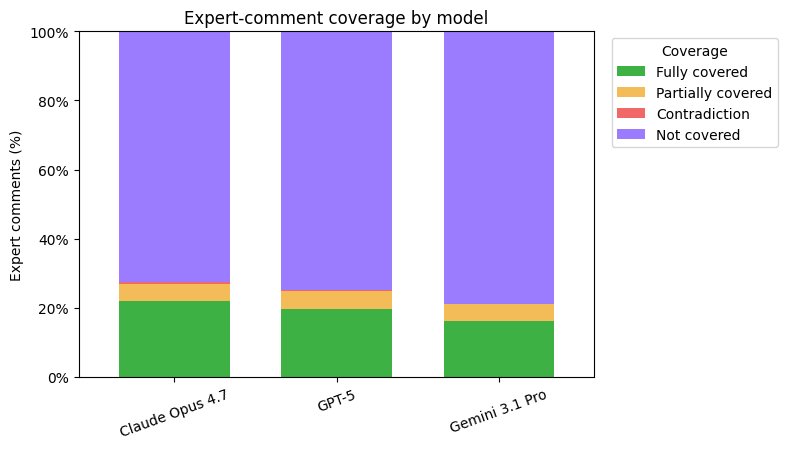

In [11]:
import matplotlib.pyplot as plt


def plot_stacked_percent_bars(summary_df, category_config, title, ylabel, legend_title, filename):
    categories = category_config["order"]
    colors = category_config["colors"]
    ax = summary_df.set_index("model_name")[categories].plot.bar(
        stacked=True,
        figsize=(8, 4.6),
        width=0.68,
        color=[colors[label] for label in categories],
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)
    ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0f}%")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_stacked_percent_bars(
    expert_coverage_summary_df,
    CATEGORY_CONFIG["coverage"],
    "Expert-comment coverage by model",
    "Expert comments (%)",
    "Coverage",
    "expert_comment_coverage_stacked.png",
)


## 9.4 LLM-Comment Groundedness Analysis

Measure how well each model's generated comments are supported by expert comments.


Derive one selected relation per LLM comment.


In [12]:
llm_groundedness_df = build_comment_alignment_df(LLM_GROUP_COLS, "expert_comment_id")
display_df(llm_groundedness_df.head(2))


,model_name,screen_task_id,llm_comment_id,expert_comment_id,best_relation,best_confidence,any_contradictory_match
0,Claude Opus 4.7,10089_T01,L_claude4_7_10089_T01_001,10089_T01_002,no_match,0.975,False
1,Claude Opus 4.7,10089_T01,L_claude4_7_10089_T01_002,10089_T01_003,B_broader,0.730,False


Collapse selected LLM-comment relations into groundedness categories.


In [13]:
llm_groundedness_summary_df = summarize_comment_categories(llm_groundedness_df, CATEGORY_CONFIG["groundedness"])
llm_groundedness_summary_df["model_short"] = pd.Categorical(llm_groundedness_summary_df["model_short"], MODEL_ORDER, ordered=True)
llm_groundedness_summary_df = llm_groundedness_summary_df.sort_values("model_short").reset_index(drop=True)

presentation_df(llm_groundedness_summary_df).to_csv(TABLES_DIR / "llm_comment_groundedness_by_model.csv", index=False)
display_df(llm_groundedness_summary_df)


,model_name,comments,Strongly grounded,Weakly grounded,Contradiction,Unsupported/extra,Any contradiction
0,Claude Opus 4.7,20149,5.9,8.1,0.2,85.8,0.2
1,GPT-5,17892,6.2,7.8,0.3,85.7,0.3
2,Gemini 3.1 Pro,9978,13.1,7.4,0.1,79.3,0.2


Visualize LLM-comment groundedness by model.


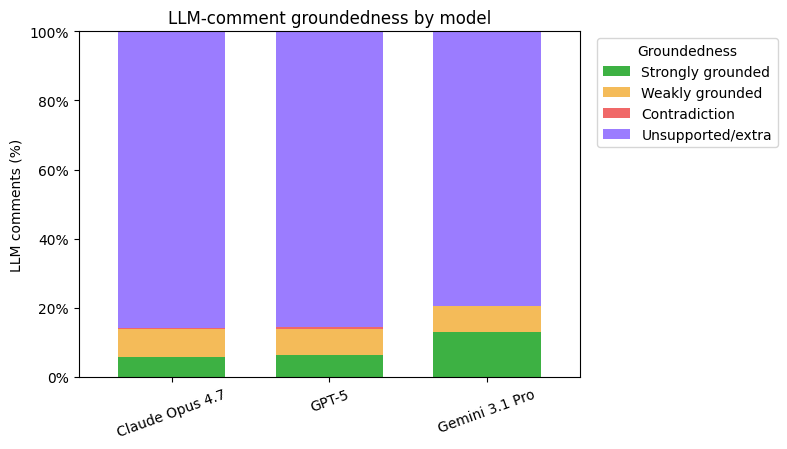

In [14]:
plot_stacked_percent_bars(
    llm_groundedness_summary_df,
    CATEGORY_CONFIG["groundedness"],
    "LLM-comment groundedness by model",
    "LLM comments (%)",
    "Groundedness",
    "llm_comment_groundedness_stacked.png",
)

Compute compact diagnostics for interpreting coverage and groundedness.


In [15]:
llm_volume_diagnostics_df = (
    llm_groundedness_df.groupby(["model_short", "model_name", "screen_task_id"], observed=False)
    .agg(llm_comments=("llm_comment_id", "nunique"))
    .groupby(["model_short", "model_name"], observed=False)["llm_comments"]
    .agg(mean_comments_per_task="mean", median_comments_per_task="median", max_comments_per_task="max")
    .round(2)
    .reset_index()
)

llm_volume_diagnostics_df["model_short"] = pd.Categorical(llm_volume_diagnostics_df["model_short"], MODEL_ORDER, ordered=True)
llm_volume_diagnostics_df = llm_volume_diagnostics_df.sort_values("model_short").reset_index(drop=True)

display_df(llm_volume_diagnostics_df)


,model_name,mean_comments_per_task,median_comments_per_task,max_comments_per_task
0,Claude Opus 4.7,6.83,7.0,11
1,GPT-5,6.07,6.0,14
2,Gemini 3.1 Pro,3.38,3.0,6


## 9.5 Combined Coverage-Groundedness Summary

Combine coverage and groundedness into a model-level summary.


In [16]:
def interpret_alignment(row: pd.Series) -> str:
    high_coverage = row["Fully + Partially covered"] >= 70
    high_groundedness = row["Strong + Weak groundedness"] >= 70
    high_unsupported = row["Unsupported/extra"] >= 30
    elevated_contradiction = row["Any contradiction"] >= 5

    if high_coverage and high_unsupported:
        label = "Broad coverage with more unsupported output"
    elif high_coverage and high_groundedness:
        label = "High coverage, high groundedness"
    elif high_groundedness:
        label = "Conservative but grounded"
    else:
        label = "Lower alignment"

    return f"{label}; contradiction caution" if elevated_contradiction else label


coverage_cols = ["model_short", "model_name", "Fully covered", "Partially covered"]
groundedness_cols = [
    "model_short",
    "Strongly grounded",
    "Weakly grounded",
    "Contradiction",
    "Unsupported/extra",
    "Any contradiction",
]

coverage_groundedness_summary_df = (
    expert_coverage_summary_df[coverage_cols]
    .merge(llm_groundedness_summary_df[groundedness_cols], on="model_short", how="inner")
)
coverage_groundedness_summary_df["Fully + Partially covered"] = (
    coverage_groundedness_summary_df["Fully covered"] + coverage_groundedness_summary_df["Partially covered"]
).round(1)
coverage_groundedness_summary_df["Strong + Weak groundedness"] = (
    coverage_groundedness_summary_df["Strongly grounded"] + coverage_groundedness_summary_df["Weakly grounded"]
).round(1)
coverage_groundedness_summary_df = coverage_groundedness_summary_df[
    [
        "model_short",
        "model_name",
        "Fully + Partially covered",
        "Strong + Weak groundedness",
        "Contradiction",
        "Unsupported/extra",
        "Any contradiction",
    ]
]
coverage_groundedness_summary_df["Interpretation"] = coverage_groundedness_summary_df.apply(interpret_alignment, axis=1)
coverage_groundedness_summary_df["model_short"] = pd.Categorical(
    coverage_groundedness_summary_df["model_short"], MODEL_ORDER, ordered=True
)
coverage_groundedness_summary_df = coverage_groundedness_summary_df.sort_values("model_short").reset_index(drop=True)

presentation_df(coverage_groundedness_summary_df).to_csv(TABLES_DIR / "coverage_groundedness_summary.csv", index=False)
display_df(coverage_groundedness_summary_df)


,model_name,Fully + Partially covered,Strong + Weak groundedness,Contradiction,Unsupported/extra,Any contradiction,Interpretation
0,Claude Opus 4.7,27.0,14.0,0.2,85.8,0.2,Lower alignment
1,GPT-5,24.8,14.0,0.3,85.7,0.3,Lower alignment
2,Gemini 3.1 Pro,21.0,20.5,0.1,79.3,0.2,Lower alignment


## 9.6 Automatic Metric Validation

Use automatic metrics as secondary validation for selected matches.


In [17]:
metric_validation_selected_df = (
    expert_coverage_df.rename(columns={"best_relation": "relation", "best_confidence": "confidence"})
    .merge(
        metric_lookup_df.drop(columns=["pair_id"], errors="ignore"),
        on=PAIR_KEYS,
        how="left",
        validate="one_to_one",
    )
)

validation_metric_cols = [
    col for col in [
        "cosine_similarity",
        "bertscore_f1",
        "llm_entails_expert_entailment",
        "llm_entails_expert_contradiction",
        "expert_entails_llm_entailment",
        "expert_entails_llm_contradiction",
    ]
    if col in metric_validation_selected_df.columns
]

metric_validation_summary_df = (
    metric_validation_selected_df.groupby("relation", observed=False)[validation_metric_cols]
    .agg(["count", "mean", "median"])
    .round(3)
)
metric_validation_summary_df.to_csv(TABLES_DIR / "automatic_metric_validation_selected_best_matches.csv")

relation_plot_order = [relation for relation in RELATION_ORDER if relation in metric_validation_selected_df["relation"].dropna().unique()]
metric_validation_plot_df = metric_validation_selected_df.copy()
metric_validation_plot_df["relation"] = pd.Categorical(
    metric_validation_plot_df["relation"], relation_plot_order, ordered=True
)

display_df(metric_validation_summary_df)


cosine_similarity               bertscore_f1         \
                                  count   mean median        count   mean   
relation                                                                    
A_broader                           850  0.475  0.475          850  0.876   
B_broader                          3165  0.494  0.499         3165  0.873   
contradiction                        97  0.485  0.490           97  0.873   
equivalent                         2896  0.575  0.585         2896  0.885   
no_match                           8747  0.202  0.194         8747  0.857   
partial_overlap                     724  0.474  0.470          724  0.875   
related_but_different             14985  0.341  0.333        14985  0.864   

                             llm_entails_expert_entailment                \
                      median                         count   mean median   
relation                                                                   
A_broader              0.874                           850  0.260  0.147   
B_broader              0.873                          3165  0.430  0.377   
contradiction          0.874                            97  0.033  0.003   
equivalent             0.883                          2896  0.437  0.371   
no_match               0.858                          8747  0.055  0.010   
partial_overlap        0.874                           724  0.164  0.052   
related_but_different  0.864                         14985  0.096  0.016   

                      llm_entails_expert_contradiction                \
                                                 count   mean median   
relation                                                               
A_broader                                          850  0.039  0.002   
B_broader                                         3165  0.070  0.003   
contradiction                                       97  0.693  0.945   
equivalent                                        2896  0.049  0.002   
no_match                                          8747  0.134  0.024   
partial_overlap                                    724  0.050  0.003   
related_but_different                            14985  0.092  0.006   

                      expert_entails_llm_entailment                \
                                              count   mean median   
relation                                                            
A_broader                                       850  0.024  0.003   
B_broader                                      3165  0.023  0.004   
contradiction                                    97  0.005  0.003   
equivalent                                     2896  0.059  0.007   
no_match                                       8747  0.026  0.007   
partial_overlap                                 724  0.021  0.005   
related_but_different                         14985  0.015  0.004   

                      expert_entails_llm_contradiction                
                                                 count   mean median  
relation                                                              
A_broader                                          850  0.035  0.002  
B_broader                                         3165  0.061  0.003  
contradiction                                       97  0.614  0.835  
equivalent                                        2896  0.048  0.002  
no_match                                          8747  0.187  0.079  
partial_overlap                                    724  0.063  0.005  
related_but_different                            14985  0.125  0.019

### 9.6.1 All-in-One Metric Boxplot

Show selected metric distributions in a compact diagnostic plot.


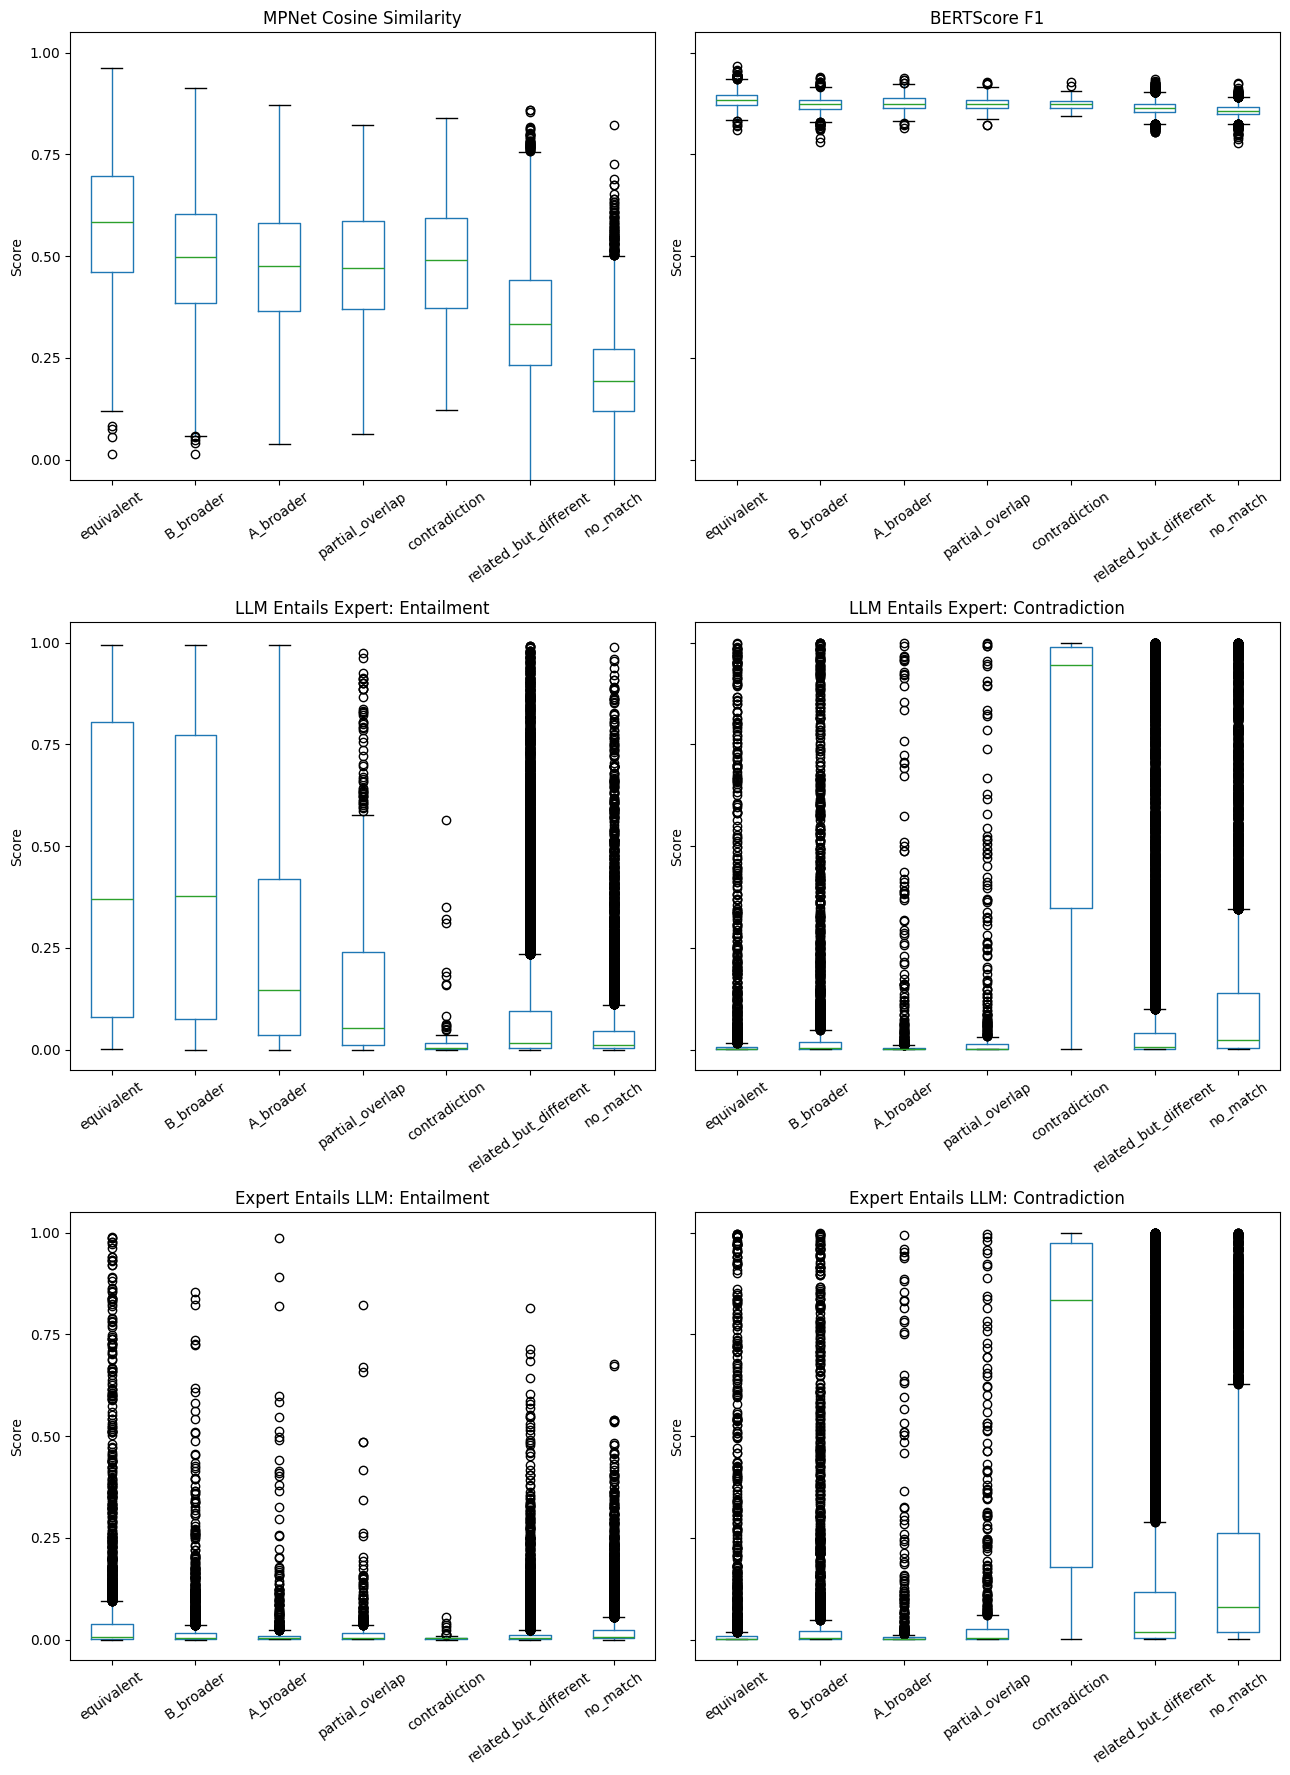

In [18]:
metric_panel_rows = [
    [
        ("cosine_similarity", "MPNet Cosine Similarity"),
        ("bertscore_f1", "BERTScore F1"),
    ],
    [
        ("llm_entails_expert_entailment", "LLM Entails Expert: Entailment"),
        ("llm_entails_expert_contradiction", "LLM Entails Expert: Contradiction"),
    ],
    [
        ("expert_entails_llm_entailment", "Expert Entails LLM: Entailment"),
        ("expert_entails_llm_contradiction", "Expert Entails LLM: Contradiction"),
    ],
]
available_metric_panels = [(metric, title) for row in metric_panel_rows for metric, title in row if metric in metric_validation_plot_df.columns]

if available_metric_panels:
    fig, axes = plt.subplots(3, 2, figsize=(13, 18), sharey=True)
    for ax, (metric, title) in zip(axes.ravel(), available_metric_panels):
        metric_validation_plot_df.boxplot(column=metric, by="relation", ax=ax, grid=False, rot=35)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("Score")
        ax.set_ylim(-0.05, 1.05)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    for ax in axes.ravel()[len(available_metric_panels):]:
        ax.set_visible(False)
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "metric_validation_all_metrics_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()


# 10. Guideline Reference Analysis

This section analyzes whether LLM critiques include guideline references and whether referenced critiques are more grounded in expert critiques.

Run this section only if `llm_guideline_reference` exists in the LLM-comment table. The unit of analysis is the unique LLM comment, not the pair row, so each generated critique contributes once.


## 10.0 Explore References

### 10.0.1 Parsing Helpers

In [19]:
import ast
import json
import re
from collections import Counter

CANONICAL_SOURCES = {"Nielsen", "Apple HIG", "CrowdCrit"}
SOURCE_RE = re.compile(
    r"(Apple Human Interface Guidelines \(HIG\)|Apple Human Interface Guidelines|Apple HIG|Nielsen Norman 10 Heuristics|Nielsen Norman Group|Nielsen Norman Heuristics?|Nielsen Norman|NN/g|Nielsen|CrowdCrit Visual Design Critiques|CrowdCrit Visual Design|CrowdCrit|CrowCrit)",
    flags=re.I,
)
SOURCE_MAP = {
    "apple human interface guidelines": "Apple HIG",
    "apple human interface guidelines (hig)": "Apple HIG",
    "apple hig": "Apple HIG",
    "nielsen norman heuristic": "Nielsen",
    "nielsen norman heuristics": "Nielsen",
    "nielsen norman 10 heuristics": "Nielsen",
    "nielsen norman group": "Nielsen",
    "nielsen norman": "Nielsen",
    "nn/g": "Nielsen",
    "nielsen": "Nielsen",
    "crowdcrit visual design critiques": "CrowdCrit",
    "crowdcrit visual design": "CrowdCrit",
    "crowdcrit": "CrowdCrit",
    "crowcrit": "CrowdCrit",
}
SOURCE_DELIMITERS = [";", "|", "."]
CATEGORY_DELIMITER_RE = re.compile(r"\s*(?:—|–|>|/|\\|:)\s*")
LEADING_CATEGORY_DELIMITER_RE = re.compile(r"^(?:—|–|-|>|/|\\|:)\s*")

NIELSEN_CATEGORIES = [
    "Visibility of System Status",
    "Match Between the System and the Real World",
    "User Control and Freedom",
    "Consistency and Standards",
    "Error Prevention",
    "Recognition Rather than Recall",
    "Flexibility and Efficiency of Use",
    "Aesthetic and Minimalist Design",
    "Help Users Recognize, Diagnose, and Recover from Errors",
    "Help and Documentation",
]
NIELSEN_CANONICAL = {
    "minimize user memory load": "Recognition Rather than Recall",
    "error recovery": "Help Users Recognize, Diagnose, and Recover from Errors",
    "match between system and the real world": "Match Between the System and the Real World",
    "match between system and real world": "Match Between the System and the Real World",
    "feedback": "Visibility of System Status",
    "Prevent errors": "Error Prevention",
    "efficiency of use": "Flexibility and Efficiency of Use",
    "visibility of system state": "Visibility of System Status",
    "aesthetics and minimalist design": "Aesthetic and Minimalist Design",
    "focus and minimalist design": "Aesthetic and Minimalist Design",
    "help users recognize and recover from errors": "Help Users Recognize, Diagnose, and Recover from Errors",
    "help users recognize and recover": "Help Users Recognize, Diagnose, and Recover from Errors",
    "Help users recognize, diagnose information": "Help Users Recognize, Diagnose, and Recover from Errors",
    "Help users recognize and understand": "Help Users Recognize, Diagnose, and Recover from Errors",
    "Help users recognize and recover from ambiguity": "Help Users Recognize, Diagnose, and Recover from Errors",
    "Help users recognize, diagnose…": "Help Users Recognize, Diagnose, and Recover from Errors",
    "Help Users Recognize, Diagnose, and Recover": "Help Users Recognize, Diagnose, and Recover from Errors",
    "Help users recognize, diagnose actions": "Help Users Recognize, Diagnose, and Recover from Errors",
    "help users recover from errors": "Help Users Recognize, Diagnose, and Recover from Errors",
    "help users prevent errors": "Error Prevention",
}

APPLE_HIG_TREE = {
    "Foundations": [
        "App icons", "Branding", "Color", "Dark Mode", "Icons", "Images", "Immersive experiences",
        "Inclusion", "Layout", "Materials", "Motion", "Privacy", "Right to left", "SF Symbols",
        "Spatial layout", "Typography", "Writing",
    ],
    "Patterns": [
        "Charting Data", "Collaboration and Sharing", "Drag and Drop", "Entering Data", "Feedback",
        "File Management", "Going Full Screen", "Launching", "Live-Viewing Apps", "Loading",
        "Managing Accounts", "Managing Notifications", "Modality", "Multitasking", "Offering Help",
        "Onboarding", "Playing Audio", "Playing Haptics", "Playing Video", "Printing",
        "Ratings and Reviews", "Searching", "Settings", "Undo and Redo", "Workouts",
    ],
    "Components": {
        "Content": ["Charts", "Image Views", "Text Views", "Web Views"],
        "Layout and Organization": ["Boxes", "Collections", "Column Views", "Disclosure Controls", "Labels", "Lists and Tables", "Lockups", "Outline Views", "Split Views", "Tab Views"],
        "Menus and Actions": ["Activity Views", "Buttons", "Context Menus", "Dock Menus", "Edit Menus", "Home Screen Quick Actions", "Menus", "Going Full Screen", "Ornaments", "Pop-up Buttons", "Pull-down Buttons", "The Menu Bar", "Toolbars"],
        "Navigation and Search": ["Path Controls", "Search Fields", "Sidebars", "Tab Bars", "Token Fields"],
        "Presentation": ["Action Sheets", "Alerts", "Page Controls", "Panels", "Popovers", "Scroll Views", "Sheets", "Windows"],
        "Selection and Input": ["Color Wells", "Combo Boxes", "Digit Entry Views", "Image Wells", "Pickers", "Segmented Controls", "Sliders", "Steppers", "Text Fields", "Toggles", "Virtual Keyboards"],
        "Status": ["Activity Rings", "Gauges", "Progress Indicators", "Rating Indicators"],
        "System Experiences": ["App Shortcuts", "Complications", "Controls", "Live Activities", "Notifications", "Snippets", "Status Bars", "Top Shelf", "Watch Faces", "Widgets"],
    },
    "Inputs": [
        "Action Button", "Apple Pencil and Scribble", "Camera Control", "Digital Crown", "Eyes",
        "Focus and Selection", "Game Controls", "Gestures", "Gyroscope and Accelerometer", "Keyboards",
        "Nearby Interactions", "Pointing Devices", "Remotes",
    ],
    "Technologies": [
        "AirPlay", "Always On", "App Clips", "Apple Pay", "Augmented Reality", "CareKit", "CarPlay",
        "Game Center", "Generative AI", "HealthKit", "HomeKit", "iCloud", "ID Verifier",
        "iMessage Apps and Stickers", "In-App Purchase", "Live Photos", "Mac Catalyst", "Machine Learning",
        "Maps", "NFC", "Photo Editing", "ResearchKit", "SharePlay", "ShazamKit", "Sign in with Apple",
        "Siri", "Tap to Pay on iPhone", "VoiceOver", "Wallet",
    ],
}


def clean_text(text):
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text).strip().strip(" .;"))


def clean_reference_text(text):
    return clean_text(LEADING_CATEGORY_DELIMITER_RE.sub("", clean_text(text)))


def normalize_key(text):
    text = clean_text(text).lower().replace("&", "and")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


NIELSEN_LOOKUP = {normalize_key(name): name for name in NIELSEN_CATEGORIES}
NIELSEN_LOOKUP.update({normalize_key(k): v for k, v in NIELSEN_CANONICAL.items()})
APPLE_TOP_LOOKUP = {normalize_key(k): k for k in APPLE_HIG_TREE}
APPLE_SUBCATEGORY_PARENT = {}
APPLE_COMPONENT_GROUPS = set(APPLE_HIG_TREE["Components"].keys())
for parent, children in APPLE_HIG_TREE.items():
    if parent == "Components":
        for group, items in children.items():
            APPLE_SUBCATEGORY_PARENT[normalize_key(group)] = ("Components", group)
            for item in items:
                APPLE_SUBCATEGORY_PARENT[normalize_key(item)] = ("Components", f"{group} / {item}")
                APPLE_SUBCATEGORY_PARENT[normalize_key(f"{group} {item}")] = ("Components", f"{group} / {item}")
    else:
        for item in children:
            APPLE_SUBCATEGORY_PARENT[normalize_key(item)] = (parent, item)

APPLE_SUBCATEGORY_ALIASES = {
    "color and contrast": ("Foundations", "Color"),
    "visual design": ("Foundations", "Layout"),
    "touch targets": ("Inputs", "Gestures"),
    "navigation bars": ("Components", "Navigation and Search"),
    "clarity": ("Foundations", "Writing"),
    "search": ("Patterns", "Searching"),
    "navigation": ("Components", "Navigation and Search"),
    "typography and color": ("Foundations", "Typography"),
    "table views": ("Components", "Lists and Tables"),
    "writing and terminology": ("Foundations", "Writing"),
    "lists": ("Components", "Lists and Tables"),
}
APPLE_SUBCATEGORY_PARENT.update({normalize_key(k): v for k, v in APPLE_SUBCATEGORY_ALIASES.items()})


def lookup_exact_or_contains(text, lookup):
    key = normalize_key(text)
    if key in lookup:
        return lookup[key]
    matches = [(k, v) for k, v in lookup.items() if k and k in key]
    if matches:
        return max(matches, key=lambda kv: len(kv[0]))[1]
    return None


def is_recognized_reference_start(text, source):
    if source == "Nielsen":
        return lookup_exact_or_contains(text, NIELSEN_LOOKUP) is not None
    if source == "Apple HIG":
        return (
            lookup_exact_or_contains(text, APPLE_TOP_LOOKUP) is not None
            or lookup_exact_or_contains(text, APPLE_SUBCATEGORY_PARENT) is not None
        )
    return True


def split_source_chunk(chunk, source):
    parts = [clean_text(part) for part in re.split(r"[|]", clean_text(chunk)) if clean_text(part)]
    period_parts = []
    for part in parts:
        period_parts.extend(re.split(r"\.\s+(?=[A-Z])", part))

    results = []
    for part in (clean_text(part) for part in period_parts if clean_text(part)):
        semicolon_parts = [clean_text(piece) for piece in part.split(";") if clean_text(piece)]
        if not semicolon_parts:
            continue
        current = semicolon_parts[0]
        for candidate in semicolon_parts[1:]:
            if is_recognized_reference_start(candidate, source):
                results.append(current)
                current = candidate
            else:
                current = f"{current}; {candidate}"
        results.append(current)
    return results


def split_category_segments(text):
    return [clean_text(seg) for seg in CATEGORY_DELIMITER_RE.split(clean_text(text)) if clean_text(seg)]


def blank_reference(source, raw_text):
    return {"source": source, "category": None, "subcategory": None, "evidence": None, "raw_reference": raw_text}


def parse_nielsen_reference(text):
    text = clean_reference_text(text)
    numbered_match = re.match(r"^Heuristic\s+\d+\s*\(\s*([^)]*?)\s*\)\s*(.*)$", text, flags=re.I)
    if numbered_match:
        category_text, trailing_text = numbered_match.groups()
        text = clean_text(f"{category_text} — {trailing_text}" if trailing_text else category_text)
    ref = blank_reference("Nielsen", text)
    normalized_text = normalize_key(text)
    matching_keys = [key for key in NIELSEN_LOOKUP if key and key in normalized_text]
    matched_key = max(matching_keys, key=len) if matching_keys else None
    category = NIELSEN_LOOKUP.get(matched_key)
    ref["category"] = category or text
    if category and matched_key:
        matched_phrase_re = r"[^a-zA-Z0-9]+".join(re.escape(token) for token in matched_key.split())
        remainder = clean_text(re.sub(matched_phrase_re, "", clean_text(text), count=1, flags=re.I))
        remainder = clean_text(CATEGORY_DELIMITER_RE.sub(" ", remainder, count=1))
        ref["evidence"] = remainder or None
    return ref


def parse_apple_reference(text):
    text = clean_reference_text(text)
    ref = blank_reference("Apple HIG", text)
    segments = split_category_segments(text) or [clean_text(text)]
    candidates = []
    for index, segment in enumerate(segments):
        top = lookup_exact_or_contains(segment, APPLE_TOP_LOOKUP)
        sub_parent = lookup_exact_or_contains(segment, APPLE_SUBCATEGORY_PARENT)
        if sub_parent:
            parent, subcategory = sub_parent
            candidates.append({"index": index, "specificity": 2, "category": parent, "subcategory": subcategory})
        elif top:
            candidates.append({"index": index, "specificity": 1, "category": top, "subcategory": None})

    if candidates:
        selected = max(candidates, key=lambda candidate: (candidate["specificity"], candidate["index"]))
        ref["category"] = selected["category"]
        ref["subcategory"] = selected["subcategory"]
        evidence_parts = [segment for index, segment in enumerate(segments) if index != selected["index"]]
    else:
        ref["category"] = segments[0]
        evidence_parts = segments[1:]

    ref["evidence"] = "; ".join(evidence_parts) or None
    return ref


def parse_crowdcrit_reference(text):
    text = clean_reference_text(text)
    ref = blank_reference("CrowdCrit", text)
    segments = split_category_segments(text)
    ref["category"] = segments[0] if segments else clean_text(text)
    ref["evidence"] = "; ".join(segments[1:]) or None
    return ref


def parse_reference_piece(source, text):
    if source == "Nielsen":
        return parse_nielsen_reference(text)
    if source == "Apple HIG":
        return parse_apple_reference(text)
    if source == "CrowdCrit":
        return parse_crowdcrit_reference(text)
    return blank_reference(source, text)


def normalize_existing_reference(ref):
    if not isinstance(ref, dict):
        return parse_reference_piece(None, clean_text(ref))
    source = SOURCE_MAP.get(normalize_key(ref.get("source")), clean_text(ref.get("source")) or None)
    raw_text = clean_text(ref.get("category"))
    parsed = parse_reference_piece(source, raw_text) if source in CANONICAL_SOURCES else blank_reference(source, raw_text)
    parsed["evidence"] = ref.get("evidence") or parsed.get("evidence")
    return parsed


def parse_structured_reference_string(text):
    stripped = clean_text(text)
    if not stripped.startswith(("[", "{")):
        return None
    for loader in (json.loads, ast.literal_eval):
        try:
            parsed = loader(stripped)
            if isinstance(parsed, list):
                return [normalize_existing_reference(ref) for ref in parsed]
            if isinstance(parsed, dict):
                return [normalize_existing_reference(parsed)]
        except Exception:
            pass
    return None


def coerce_reference_sequence(value):
    if isinstance(value, (list, tuple)):
        return list(value)
    if hasattr(value, "tolist"):
        coerced = value.tolist()
        return coerced if isinstance(coerced, list) else [coerced]
    return None


def parse_guideline_references(value):
    sequence = coerce_reference_sequence(value)
    if sequence is not None:
        return [normalize_existing_reference(ref) for ref in sequence]
    if isinstance(value, dict):
        return [normalize_existing_reference(value)]
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    structured_refs = parse_structured_reference_string(value)
    if structured_refs is not None:
        return structured_refs

    text = clean_text(value)
    matches = list(SOURCE_RE.finditer(text))
    refs = []
    for i, match in enumerate(matches):
        source = SOURCE_MAP[match.group(1).lower()]
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        for piece in split_source_chunk(text[start:end], source):
            pieces = re.split(r",\s*(?=Heuristic\s+\d+\b)", piece, flags=re.I) if source == "Nielsen" else [piece]
            refs.extend(parse_reference_piece(source, subpiece) for subpiece in pieces if clean_text(subpiece))
    return refs


def invalid_values(refs, source, field, valid_lookup=None, allow_missing=False):
    values = []
    for ref in refs:
        if ref.get("source") != source:
            continue
        value = ref.get(field)
        if not value:
            if not allow_missing:
                values.append(value)
        elif valid_lookup is not None and normalize_key(value) not in valid_lookup:
            values.append(value)
    return values


def build_parsed_long_df(refs):
    return (
        refs.explode("parsed_guideline_references")
        .dropna(subset=["parsed_guideline_references"])
        .reset_index(drop=True)
        .assign(
            source=lambda d: d["parsed_guideline_references"].apply(lambda r: r.get("source")),
            category=lambda d: d["parsed_guideline_references"].apply(lambda r: r.get("category")),
            subcategory=lambda d: d["parsed_guideline_references"].apply(lambda r: r.get("subcategory")),
            evidence=lambda d: d["parsed_guideline_references"].apply(lambda r: r.get("evidence")),
            raw_reference=lambda d: d["parsed_guideline_references"].apply(lambda r: r.get("raw_reference")),
        )
    )


def print_reference_examples(title, mask, n=5):
    mask = mask.fillna(False).astype(bool)
    print(f"{title}: {int(mask.sum())}")
    for model_short in MODEL_ORDER:
        model_mask = mask & refs_df["model_short"].eq(model_short)
        rows = refs_df.loc[model_mask].head(n)
        print(f"\n{model_short}: {int(model_mask.sum())}")
        for _, row in rows.iterrows():
            print(f"comment: {row['llm_comment_id']}")
            print("llm_guideline_reference:")
            print(row["llm_guideline_reference"])
            print("parsed_guideline_references:")
            print(row["parsed_guideline_references"])
            print("---")


def print_invalid_summary(title, column, n=50):
    print(title)
    for model_short in MODEL_ORDER:
        values = [v for values in refs_df.loc[refs_df["model_short"].eq(model_short), column] for v in values]
        print(f"\n{model_short}: {len(values)}")
        print("unique values:")
        for value, count in Counter(values).most_common(n):
            print(f"{count:>4}  {value}")

### 10.0.2 Apply Parser

Apply the reference parser to each unique LLM comment and derive diagnostic flags for parsing quality and formatting patterns.

In [20]:
refs_df = (
    all_pairs_df[["model_short", "model_name", "llm_comment_id", "llm_guideline_reference"]]
    .drop_duplicates(["model_short", "llm_comment_id"])
    .copy()
)
refs_df["parsed_guideline_references"] = refs_df["llm_guideline_reference"].apply(parse_guideline_references)
refs_df["reference_missing"] = refs_df["llm_guideline_reference"].isna()
refs_df["parse_failed"] = (
    ~refs_df["reference_missing"]
    & refs_df["parsed_guideline_references"].str.len().eq(0)
)
refs_df["raw_source_mentions"] = refs_df["llm_guideline_reference"].fillna("").astype(str).apply(lambda x: [m.group(1) for m in SOURCE_RE.finditer(x)])
refs_df["source_mentions"] = refs_df["raw_source_mentions"].apply(lambda xs: [SOURCE_MAP[x.lower()] for x in xs])
refs_df["multiple_references_same_source"] = refs_df["parsed_guideline_references"].apply(
    lambda refs: len([ref.get("source") for ref in refs])
    != len(set(ref.get("source") for ref in refs))
)
refs_df["source_alias_used"] = refs_df["raw_source_mentions"].apply(lambda xs: any(x not in CANONICAL_SOURCES for x in xs))
def is_sentence_like_unrecognized_category(ref):
    source = ref.get("source")
    category = ref.get("category") or ""
    category_key = normalize_key(category)
    if source == "Nielsen":
        recognized = category_key in NIELSEN_LOOKUP
    elif source == "Apple HIG":
        recognized = category_key in APPLE_TOP_LOOKUP
    else:
        return False
    return not recognized and len(category.split()) >= 8


refs_df["sentence_like_unrecognized_category"] = refs_df["parsed_guideline_references"].apply(
    lambda refs: any(is_sentence_like_unrecognized_category(ref) for ref in refs)
)
refs_df["leading_delimiter_in_category"] = refs_df["parsed_guideline_references"].apply(
    lambda refs: any(
        re.match(r"^\s*[-—–>|/:]", ref.get("category") or "")
        for ref in refs
    )
)
refs_df["has_period_source_sep"] = refs_df["llm_guideline_reference"].fillna("").astype(str).str.contains(r"\.\s+(?:Apple|Nielsen|CrowdCrit)", regex=True, na=False)
refs_df["has_pipe_sep"] = refs_df["llm_guideline_reference"].fillna("").astype(str).str.contains(r"\|", na=False)
refs_df["invalid_source_values"] = refs_df["parsed_guideline_references"].apply(lambda refs: [r.get("source") for r in refs if r.get("source") not in CANONICAL_SOURCES])
refs_df["invalid_nielsen_category_values"] = refs_df["parsed_guideline_references"].apply(lambda refs: invalid_values(refs, "Nielsen", "category", NIELSEN_LOOKUP))
refs_df["invalid_apple_category_values"] = refs_df["parsed_guideline_references"].apply(lambda refs: invalid_values(refs, "Apple HIG", "category", APPLE_TOP_LOOKUP))
refs_df["invalid_apple_subcategory_values"] = refs_df["parsed_guideline_references"].apply(lambda refs: invalid_values(refs, "Apple HIG", "subcategory", APPLE_SUBCATEGORY_PARENT, allow_missing=True))
refs_df["bad_source"] = refs_df["invalid_source_values"].str.len().gt(0)
refs_df["invalid_nielsen_category"] = refs_df["invalid_nielsen_category_values"].str.len().gt(0)
refs_df["invalid_apple_category"] = refs_df["invalid_apple_category_values"].str.len().gt(0)
refs_df["invalid_apple_subcategory"] = refs_df["invalid_apple_subcategory_values"].str.len().gt(0)
parsed_long_df = build_parsed_long_df(refs_df)

print("Rows by model")
print(refs_df.groupby("model_short").size().to_dict())
print("Missing references by model")
print(refs_df.groupby("model_short")["reference_missing"].sum().astype(int).to_dict())
print("Genuine parse failures by model")
print(refs_df.groupby("model_short")["parse_failed"].sum().astype(int).to_dict())

Rows by model
{'claude4_7': 20149, 'gemini3_1pro': 9978, 'gpt5': 17892}
Missing references by model
{'claude4_7': 0, 'gemini3_1pro': 0, 'gpt5': 1}
Genuine parse failures by model
{'claude4_7': 0, 'gemini3_1pro': 0, 'gpt5': 0}


### 10.0.3 Parse Failures

Report missing references separately from genuine failures where nonmissing text could not be parsed.

In [21]:
print_reference_examples("reference_missing", refs_df["reference_missing"], n=10)
print()
print_reference_examples("parse_failed", refs_df["parse_failed"], n=10)

reference_missing: 1

claude4_7: 0

gpt5: 1
comment: L_gpt5_39697_T02_001
llm_guideline_reference:
nan
parsed_guideline_references:
[]
---

gemini3_1pro: 0

parse_failed: 0

claude4_7: 0

gpt5: 0

gemini3_1pro: 0


### 10.0.4 Source Label Issues

Summarize invalid source labels and separately inspect accepted source-name aliases used in the raw references.

In [22]:
print_invalid_summary("invalid source values", "invalid_source_values")
print()
print_reference_examples("bad_source", refs_df["bad_source"], n=10)
print()
print_reference_examples("source_alias_used", refs_df["source_alias_used"], n=10)

invalid source values

claude4_7: 0
unique values:

gpt5: 0
unique values:

gemini3_1pro: 0
unique values:

bad_source: 0

claude4_7: 0

gpt5: 0

gemini3_1pro: 0

source_alias_used: 17814

claude4_7: 0

gpt5: 17814
comment: L_gpt5_10089_T01_001
llm_guideline_reference:
Nielsen Norman: Heuristic 6 (Recognition rather than recall), Heuristic 4 (Consistency and standards); Apple Human Interface Guidelines: Controls—Buttons should look tappable; Visual Design—Clarity; Use standard controls for selection.
parsed_guideline_references:
[{'source': 'Nielsen', 'category': 'Recognition Rather than Recall', 'subcategory': None, 'evidence': None, 'raw_reference': 'Recognition rather than recall'}, {'source': 'Nielsen', 'category': 'Consistency and Standards', 'subcategory': None, 'evidence': None, 'raw_reference': 'Consistency and standards'}, {'source': 'Apple HIG', 'category': 'Components', 'subcategory': 'Menus and Actions / Buttons', 'evidence': 'Controls', 'raw_reference': 'Controls—Buttons s

### 10.0.5 Multiple References from the Same Source

Identify comments with multiple parsed references from the same guideline framework and inspect representative examples.

In [23]:
print_reference_examples("multiple_references_same_source", refs_df["multiple_references_same_source"], n=10)

multiple_references_same_source: 9492

claude4_7: 1082
comment: L_claude4_7_10112_T01_001
llm_guideline_reference:
[{'source': 'Nielsen', 'category': 'Consistency and standards', 'evidence': 'Two buttons using nearly identical labels for different functions violates the principle that different actions should not look or read the same.'}
 {'source': 'Nielsen', 'category': 'Recognition rather than recall', 'evidence': "Users must guess which 'Login' refers to which method instead of recognizing the action from the label."}]
parsed_guideline_references:
[{'source': 'Nielsen', 'category': 'Consistency and Standards', 'subcategory': None, 'evidence': 'Two buttons using nearly identical labels for different functions violates the principle that different actions should not look or read the same.', 'raw_reference': 'Consistency and standards'}, {'source': 'Nielsen', 'category': 'Recognition Rather than Recall', 'subcategory': None, 'evidence': "Users must guess which 'Login' refers to which 

### 10.0.6 Separator Patterns

Examine references that separate sources with periods or pipes to verify that these formatting variants are parsed correctly.

In [24]:
print_reference_examples("has_period_source_sep", refs_df["has_period_source_sep"], n=10)

has_period_source_sep: 6895

claude4_7: 0

gpt5: 6895
comment: L_gpt5_10089_T02_001
llm_guideline_reference:
Nielsen Norman: Flexibility and efficiency of use; Recognition rather than recall. Apple Human Interface Guidelines: Search and Filters — Help people find content quickly; Use controls (segmented controls, menus) to refine large data sets.
parsed_guideline_references:
[{'source': 'Nielsen', 'category': 'Flexibility and Efficiency of Use', 'subcategory': None, 'evidence': None, 'raw_reference': 'Flexibility and efficiency of use'}, {'source': 'Nielsen', 'category': 'Recognition Rather than Recall', 'subcategory': None, 'evidence': None, 'raw_reference': 'Recognition rather than recall'}, {'source': 'Apple HIG', 'category': 'Components', 'subcategory': 'Content', 'evidence': 'Search and Filters', 'raw_reference': 'Search and Filters — Help people find content quickly'}, {'source': 'Apple HIG', 'category': 'Components', 'subcategory': 'Selection and Input / Segmented Controls', 'ev

In [25]:
print_reference_examples("has_pipe_sep", refs_df["has_pipe_sep"], n=10)

has_pipe_sep: 42

claude4_7: 0

gpt5: 42
comment: L_gpt5_37261_T02_001
llm_guideline_reference:
Nielsen Norman: Recognition rather than recall; Consistency and standards. | Apple Human Interface Guidelines: Navigation Bars — Use text for actionable buttons; Avoid ambiguous icons.
parsed_guideline_references:
[{'source': 'Nielsen', 'category': 'Recognition Rather than Recall', 'subcategory': None, 'evidence': None, 'raw_reference': 'Recognition rather than recall'}, {'source': 'Nielsen', 'category': 'Consistency and Standards', 'subcategory': None, 'evidence': None, 'raw_reference': 'Consistency and standards'}, {'source': 'Apple HIG', 'category': 'Components', 'subcategory': 'Menus and Actions / Buttons', 'evidence': 'Navigation Bars', 'raw_reference': 'Navigation Bars — Use text for actionable buttons'}, {'source': 'Apple HIG', 'category': 'Foundations', 'subcategory': 'Icons', 'evidence': None, 'raw_reference': 'Avoid ambiguous icons'}]
---
comment: L_gpt5_37261_T02_002
llm_guideline

### 10.0.7 Post-Parse Category Checks

Conservatively flag only unrecognized sentence-like Nielsen or Apple categories and category values that retain a leading delimiter; these checks surface likely parser artifacts without requiring rules for every wording variation.

In [26]:
print_reference_examples("sentence_like_unrecognized_category", refs_df["sentence_like_unrecognized_category"], n=10)
print()
print_reference_examples("leading_delimiter_in_category", refs_df["leading_delimiter_in_category"], n=10)

sentence_like_unrecognized_category: 440

claude4_7: 1
comment: L_claude4_7_56472_T02_007
llm_guideline_reference:
[{'source': 'Nielsen', 'category': 'Help users recognize the value of their action', 'evidence': 'Without context, users cannot judge whether subscribing is worthwhile.'}
 {'source': 'CrowdCrit', 'category': 'Content / Motivation', 'evidence': 'Persuasive CTAs require visible value before commitment.'}]
parsed_guideline_references:
[{'source': 'Nielsen', 'category': 'Help users recognize the value of their action', 'subcategory': None, 'evidence': 'Without context, users cannot judge whether subscribing is worthwhile.', 'raw_reference': 'Help users recognize the value of their action'}, {'source': 'CrowdCrit', 'category': 'Content', 'subcategory': None, 'evidence': 'Persuasive CTAs require visible value before commitment.', 'raw_reference': 'Content / Motivation'}]
---

gpt5: 439
comment: L_gpt5_10122_T02_005
llm_guideline_reference:
Nielsen Norman — Error prevention; Reco

### 10.0.8 Known NN/Apple Category Checks

List unrecognized Nielsen and Apple HIG categories or subcategories to assess normalization coverage.

In [27]:
print_invalid_summary("invalid Nielsen categories", "invalid_nielsen_category_values")
print()
print_reference_examples("invalid_nielsen_category", refs_df["invalid_nielsen_category"], n=10)
print()
print_invalid_summary("invalid Apple categories", "invalid_apple_category_values")
print()
print_reference_examples("invalid_apple_category", refs_df["invalid_apple_category"], n=10)
print()
print_invalid_summary("invalid Apple subcategories", "invalid_apple_subcategory_values")
print()
print_reference_examples("invalid_apple_subcategory", refs_df["invalid_apple_subcategory"], n=10)

invalid Nielsen categories

claude4_7: 5
unique values:
   1  Help Users Make Informed Choices
   1  Accessibility / Readability
   1  Affordance / Visibility
   1  Help users recognize the value of their action
   1  Affordance / Signifiers

gpt5: 9
unique values:
   1  Accessibility is usability
   1  Affordance
   1  Accessibility is usability (legibility supports recognition)
   1  Accessibility (help users with diverse abilities)
   1  Accessibility (support readability to prevent user errors)
   1  Accessibility as part of usability
   1  Accessibility as a quality component
   1  Fitts’s Law
   1  Accessibility as a core usability requirement

gemini3_1pro: 7
unique values:
   7  Discoverability

invalid_nielsen_category: 21

claude4_7: 5
comment: L_claude4_7_46606_T01_007
llm_guideline_reference:
[{'source': 'Nielsen', 'category': 'Help Users Make Informed Choices', 'evidence': 'Providing relevant metadata helps users select tasks confidently.'}
 {'source': 'CrowdCrit', 'catego

### 10.0.9 Explore Guidance Paraphrases

Search raw and parsed Apple HIG fields for a selected phrase, then inspect a bounded set of matching comments before deciding whether a recurring paraphrase warrants normalization.


In [28]:
guidance_phrase = "Color and Contrast"
guidance_model = "gpt5"
guidance_max_examples = 25

comment_context_cols = [
    col for col in [
        "model_short", "model_name", "llm_comment_id", "screen_task_id", "screen_id", "task",
        "llm_comment", "llm_comment_text", "llm_response", "comment", "critique"
    ]
    if col in all_pairs_df.columns
]
llm_comment_context_df = all_pairs_df[comment_context_cols].drop_duplicates(["model_short", "llm_comment_id"])

phrase_key = normalize_key(guidance_phrase)
if not phrase_key:
    raise ValueError("Set guidance_phrase to the Apple HIG guidance phrase you want to inspect.")

guidance_search_fields = ["raw_reference", "category", "subcategory", "evidence"]
apple_guidance_df = parsed_long_df.loc[
    parsed_long_df["model_short"].eq(guidance_model)
    & parsed_long_df["source"].eq("Apple HIG")
].copy()
apple_guidance_df["matched_fields"] = apple_guidance_df.apply(
    lambda row: [
        field for field in guidance_search_fields
        if phrase_key in normalize_key(row.get(field))
    ],
    axis=1,
)

guidance_phrase_cases_df = (
    apple_guidance_df.loc[apple_guidance_df["matched_fields"].str.len().gt(0)]
    .merge(llm_comment_context_df, on=["model_short", "model_name", "llm_comment_id"], how="left")
    .sort_values(["category", "llm_comment_id"])
)

comment_text_col = next((col for col in ["llm_comment", "llm_comment_text", "llm_response", "comment", "critique"] if col in guidance_phrase_cases_df.columns), None)

print(f"{guidance_model} Apple HIG guidance phrase cases for {guidance_phrase!r}: {len(guidance_phrase_cases_df)}")
print(f"Showing up to {guidance_max_examples} examples.")
for _, row in guidance_phrase_cases_df.head(guidance_max_examples).iterrows():
    print("\n" + "=" * 80)
    print(f"comment_id: {row['llm_comment_id']}")
    print(f"screen_task_id: {row.get('screen_task_id', '')}")
    print(f"category: {row['category']}")
    print(f"subcategory: {row['subcategory']}")
    print(f"matched_fields: {row['matched_fields']}")
    print(f"guideline_reference: {row['llm_guideline_reference']}")
    print(f"parsed_guideline_references: {row['parsed_guideline_references']}")
    if comment_text_col:
        print(f"comment: {row[comment_text_col]}")


gpt5 Apple HIG guidance phrase cases for 'Color and Contrast': 1342
Showing up to 25 examples.

comment_id: L_gpt5_12185_T02_005
screen_task_id: 12185_T02
category: Components
subcategory: System Experiences / Controls
matched_fields: ['raw_reference', 'evidence']
guideline_reference: Apple Human Interface Guidelines: Color and Contrast—ensure sufficient contrast for text and controls. CrowdCrit Visual Design: Emphasis and contrast. Nielsen Norman: Visibility of system status (clearly indicate enabled vs disabled).
parsed_guideline_references: {'source': 'Apple HIG', 'category': 'Components', 'subcategory': 'System Experiences / Controls', 'evidence': 'Color and Contrast', 'raw_reference': 'Color and Contrast—ensure sufficient contrast for text and controls'}

comment_id: L_gpt5_18262_T03_003
screen_task_id: 18262_T03
category: Components
subcategory: System Experiences / Controls
matched_fields: ['raw_reference', 'evidence']
guideline_reference: Nielsen Norman: Consistency and standar

In [29]:
print_invalid_summary("invalid Apple categories", "invalid_apple_category_values", 50)


invalid Apple categories

claude4_7: 429
unique values:
  46  Iconography
  25  Accessibility
  22  Empty States
  18  Visual Hierarchy
  16  Data Entry
  14  Sharing
  13  Tables
  13  Links
  13  Affordance
  12  Requesting Permission
   9  Destructive Actions
   9  Consistency
   9  Aesthetic Integrity
   7  Bars
   6  Destructive actions
   6  Localization
   6  Selection and state
   6  Information Architecture
   6  Disclosure Indicators
   6  Terminology
   6  Advertising
   5  Interactivity
   5  Selection and State
   5  Visual hierarchy
   5  Actions
   5  Badges
   4  Personalization
   3  Secure Text Field
   3  Tap targets
   3  Data entry
   3  Affordances
   3  Inclusivity
   3  Selection States
   3  Selection states
   3  Location
   3  Platform Consistency
   3  Selection and state indication
   3  Disclosure indicators
   3  Information design
   3  Platform Conventions
   3  Focus and Primary Action
   3  Selection and Tabs
   2  Data formatting
   2  Selection indi

### 10.0.10 Normalize Valid-ish Apple HIG Concepts

Map recognizable Apple HIG paraphrases to canonical concepts, reparse the references, and report the remaining invalid categories.


In [30]:
VALIDISH_APPLE_HIG_ALIASES = {
    "Iconography": ("Foundations", "Icons"),
    "Terminology": ("Foundations", "Writing"),
    "Requesting Permission": ("Foundations", "Privacy"),
    "touch target": ("Foundations", "Layout"),
    "touch targets": ("Foundations", "Layout"),
    "writing and terminology": ("Foundations", "Writing"),
    "typography and color": ("Foundations", "Typography"),
    "color and contrast": ("Foundations", "Color"),
    "Data Entry": ("Patterns", "Entering Data"),
    "search": ("Patterns", "Searching"),
    "Authentication": ("Patterns", "Managing Accounts"),
    "Sharing": ("Patterns", "Collaboration and Sharing"),
    "text input": ("Components", "Selection and Input / Text Fields"),
    "Secure Text Entry": ("Components", "Selection and Input / Text Fields"),
    "Secure Text Field": ("Components", "Selection and Input / Text Fields"),
    "Switches": ("Components", "Selection and Input / Toggles"),
    "Tables": ("Components", "Layout and Organization / Lists and Tables"),
    "table views": ("Components", "Layout and Organization / Lists and Tables"),
    "navigation bars": ("Components", "Navigation and Search"),
    "navigation": ("Components", "Navigation and Search"),
    "Lists": ("Components", "Layout and Organization / Lists and Tables"),
    "Table views": ("Components", "Layout and Organization / Lists and Tables"),
    "Page Control": ("Components", "Presentation / Page Controls"),
    "Disclosure Indicators": ("Components", "Layout and Organization / Disclosure Controls"),
}

APPLE_SUBCATEGORY_PARENT.update({
    normalize_key(alias): target
    for alias, target in VALIDISH_APPLE_HIG_ALIASES.items()
})

refs_df["parsed_guideline_references"] = refs_df["llm_guideline_reference"].apply(parse_guideline_references)
refs_df["invalid_apple_category_values"] = refs_df["parsed_guideline_references"].apply(
    lambda refs: invalid_values(refs, "Apple HIG", "category", APPLE_TOP_LOOKUP)
)
refs_df["invalid_apple_subcategory_values"] = refs_df["parsed_guideline_references"].apply(
    lambda refs: invalid_values(refs, "Apple HIG", "subcategory", APPLE_SUBCATEGORY_PARENT, allow_missing=True)
)
refs_df["invalid_apple_category"] = refs_df["invalid_apple_category_values"].str.len().gt(0)
refs_df["invalid_apple_subcategory"] = refs_df["invalid_apple_subcategory_values"].str.len().gt(0)

parsed_long_df = build_parsed_long_df(refs_df)

normalized_alias_rows = parsed_long_df.loc[
    parsed_long_df["source"].eq("Apple HIG")
    & parsed_long_df["subcategory"].isin({target[1] for target in VALIDISH_APPLE_HIG_ALIASES.values()})
]
print(f"Valid-ish Apple HIG alias rows normalized: {len(normalized_alias_rows)}")
print_invalid_summary("invalid Apple categories after valid-ish aliases", "invalid_apple_category_values")


Valid-ish Apple HIG alias rows normalized: 21492
invalid Apple categories after valid-ish aliases

claude4_7: 289
unique values:
  24  Accessibility
  22  Empty States
  18  Visual Hierarchy
  13  Links
  13  Affordance
   9  Destructive Actions
   9  Aesthetic Integrity
   8  Consistency
   6  Bars
   6  Destructive actions
   6  Localization
   6  Selection and state
   6  Information Architecture
   6  Advertising
   5  Interactivity
   5  Selection and State
   5  Visual hierarchy
   5  Badges
   4  Personalization
   4  Actions
   3  Tap targets
   3  Affordances
   3  Inclusivity
   3  Selection States
   3  Selection states
   3  Location
   3  Platform Consistency
   3  Selection and state indication
   3  Information design
   3  Platform Conventions
   3  Focus and Primary Action
   3  Selection and Tabs
   2  Data formatting
   2  Selection indicators
   2  User Control
   2  Tap Targets
   2  Date and Time
   2  Focus and Hierarchy
   2  Information architecture
   2  Platf

## 10.1 Reference Presence

Check that every unique LLM comment has a guideline-reference field and at least one parsed reference.


In [31]:
parsed_long_df = build_parsed_long_df(refs_df)

def display_by_model(df, model_col="model_short"):
    for model in MODEL_ORDER:
        model_df = df.loc[df[model_col].eq(model)].copy()
        if model_df.empty:
            continue
        print(f"\n{model}")
        display(model_df.reset_index(drop=True))

reference_presence_df = refs_df.assign(
    has_guideline_reference=refs_df["llm_guideline_reference"].notna()
    & refs_df["llm_guideline_reference"].astype(str).str.strip().ne(""),
    parsed_reference_count=refs_df["parsed_guideline_references"].str.len(),
)
reference_presence_df["parsed_reference_count_when_present"] = (
    reference_presence_df["parsed_reference_count"].where(reference_presence_df["has_guideline_reference"])
)
reference_presence_df["unparsed_nonmissing_reference"] = (
    reference_presence_df["has_guideline_reference"]
    & reference_presence_df["parsed_reference_count"].eq(0)
)

guideline_reference_presence_df = (
    reference_presence_df.groupby(["model_short", "model_name"], observed=True)
    .agg(
        llm_comments=("llm_comment_id", "nunique"),
        comments_with_reference=("has_guideline_reference", "sum"),
        min_parsed_references_when_present=("parsed_reference_count_when_present", "min"),
        unparsed_nonmissing_references=("unparsed_nonmissing_reference", "sum"),
    )
    .reset_index()
)
guideline_reference_presence_df["missing_references"] = (
    guideline_reference_presence_df["llm_comments"]
    - guideline_reference_presence_df["comments_with_reference"]
)
guideline_reference_presence_df["model_short"] = pd.Categorical(
    guideline_reference_presence_df["model_short"], MODEL_ORDER, ordered=True
)
guideline_reference_presence_df = guideline_reference_presence_df.sort_values("model_short")

assert guideline_reference_presence_df["unparsed_nonmissing_references"].eq(0).all()
display(guideline_reference_presence_df)


,model_short,model_name,llm_comments,comments_with_reference,min_parsed_references_when_present,unparsed_nonmissing_references,missing_references
0,claude4_7,Claude Opus 4.7,20149,20149,1.0,0,0
2,gpt5,GPT-5,17892,17891,1.0,0,1
1,gemini3_1pro,Gemini 3.1 Pro,9978,9978,1.0,0,0


## 10.2 Guideline Focus

This section stays at the unique LLM-comment/reference level and summarizes which guideline concepts were repeatedly cited. All three figures use grouped horizontal bars, consistent model colors, and direct percentage labels so that models can be compared on a common baseline. The category construction remains framework-specific: Nielsen uses its fixed canonical taxonomy, Apple HIG uses a compact set of shared concept bins, and CrowdCrit uses broader focus groups derived from its noisier free-text labels.


In [32]:
top_n = 20

### 10.2.1 Nielsen Heuristic Distribution

The figure presents Nielsen's canonical 10 heuristics in their original numbered order. Each row contains one bar per model, and percentages are calculated within each model's successfully mapped Nielsen references. Non-canonical Nielsen-attributed labels are excluded from this denominator and retained in the parser diagnostics. The shared horizontal scale supports direct comparison while preserving the complete heuristic names.


In [ ]:
def ranked_reference_percentages(df, label_col, value_name, top_n=None):
    summary_df = (
        df.dropna(subset=[label_col])
        .groupby(["model_short", "model_name", label_col], observed=True)
        .size()
        .rename("reference_count")
        .reset_index()
        .rename(columns={label_col: value_name})
    )
    totals = summary_df.groupby(["model_short", "model_name"], observed=True)["reference_count"].transform("sum")
    summary_df["pct_references"] = summary_df["reference_count"] / totals * 100
    summary_df["rank"] = (
        summary_df.groupby("model_short", observed=True)["reference_count"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    summary_df["model_short"] = pd.Categorical(summary_df["model_short"], MODEL_ORDER, ordered=True)
    summary_df = summary_df.sort_values(["model_short", "rank"])
    if top_n is not None:
        summary_df = summary_df.loc[summary_df["rank"].le(top_n)]
    return summary_df.reset_index(drop=True)

nielsen_refs_df = (
    parsed_long_df.loc[
        parsed_long_df["source"].eq("Nielsen")
        & parsed_long_df["category"].isin(NIELSEN_CATEGORIES)
    ]
    .reset_index(drop=True)
)
nielsen_model_order = [MODEL_DISPLAY[model] for model in MODEL_ORDER]

nielsen_heuristic_table_df = (
    pd.crosstab(nielsen_refs_df["category"], nielsen_refs_df["model_name"], normalize="columns")
    .mul(100)
    .reindex(index=NIELSEN_CATEGORIES, columns=nielsen_model_order)
    .fillna(0)
)
nielsen_heuristic_percent_df = (
    nielsen_heuristic_table_df
    .rename_axis(index="category", columns="model_name")
    .stack()
    .rename("pct_nielsen_references")
    .reset_index()
)

display(nielsen_heuristic_table_df.round(2))

model_name,Claude Opus 4.7,GPT-5,Gemini 3.1 Pro
category,,,
Visibility of System Status,25.95,12.72,14.42
Match Between the System and the Real World,14.61,14.55,18.72
User Control and Freedom,7.30,3.83,3.50
Consistency and Standards,9.54,21.19,25.84
Error Prevention,5.66,10.60,7.22
Recognition Rather than Recall,17.31,15.23,6.63
Flexibility and Efficiency of Use,4.28,4.08,3.06
Aesthetic and Minimalist Design,9.04,14.51,18.50
"Help Users Recognize, Diagnose, and Recover from Errors",2.59,1.45,0.82


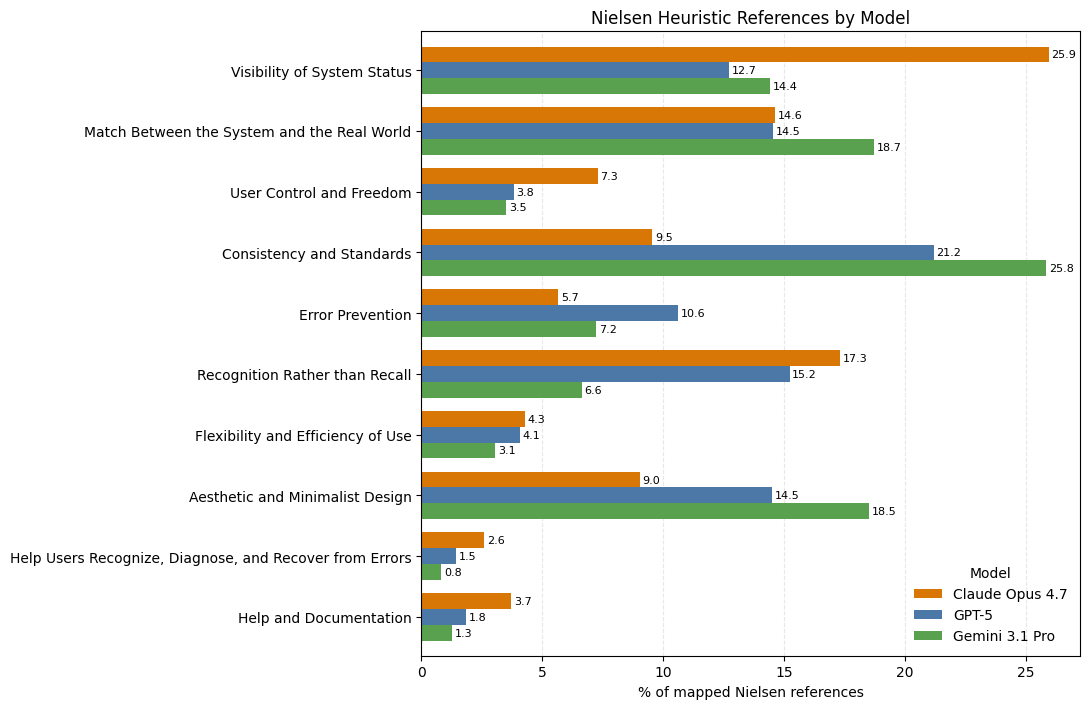

In [34]:
import matplotlib.pyplot as plt


def save_guideline_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


nielsen_plot_df = (
    nielsen_heuristic_percent_df
    .pivot(index="category", columns="model_name", values="pct_nielsen_references")
    .reindex(index=NIELSEN_CATEGORIES, columns=[MODEL_DISPLAY[model] for model in MODEL_ORDER])
    .fillna(0)
)
model_colors = {
    MODEL_DISPLAY["claude4_7"]: "#D97706",
    MODEL_DISPLAY["gpt5"]: "#4C78A8",
    MODEL_DISPLAY["gemini3_1pro"]: "#59A14F",
}

ax = nielsen_plot_df.plot.barh(
    figsize=(11, 7.2),
    width=0.78,
    color=[model_colors[column] for column in nielsen_plot_df.columns],
)
ax.invert_yaxis()
ax.set_title("Nielsen Heuristic References by Model")
ax.set_xlabel("% of mapped Nielsen references")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)
ax.legend(title="Model", loc="lower right", frameon=False)
save_guideline_figure("guideline_nielsen.png")


For Nielsen heuristics, the models concentrate on different parts of the framework. Claude Opus 4.7 most often cites `Visibility of System Status` (25.95%) and `Recognition Rather than Recall` (17.31%), suggesting that its references often frame issues around whether the interface makes state and available actions apparent. GPT-5 emphasizes `Consistency and Standards` (21.19%), followed by `Recognition Rather than Recall` (15.23%), `Match Between the System and the Real World` (14.55%), and `Aesthetic and Minimalist Design` (14.51%). Gemini 3.1 Pro is also most concentrated on `Consistency and Standards` (25.84%), with `Match Between the System and the Real World` (18.72%) and `Aesthetic and Minimalist Design` (18.50%) as secondary themes. Across models, `Help Users Recognize, Diagnose, and Recover from Errors` and `Help and Documentation` are rarely cited, which is expected for static screenshot critiques where error recovery and help content are often not directly observable. The calculation excludes 21 Nielsen-attributed labels that do not match the canonical taxonomy (5 Claude, 9 GPT-5, and 7 Gemini); these cases are retained in the parser diagnostics rather than treated as heuristics.


### 10.2.2 Apple HIG Concept Distribution

For reporting, Apple HIG category and subcategory are merged into one derived concept label when the subcategory is known; the underlying parser output is unchanged. The figure uses the nine mapped concepts with the largest pooled reference counts across all three models, ordered by that pooled frequency. A tenth `Other (including unmapped / non-canonical)` bin combines every remaining mapped concept with all unmapped labels. Consequently, the 10 bins are exhaustive and each model's percentages sum to 100% before rounding. The shared bins and horizontal scale permit direct comparisons across models.


In [35]:
def clean_reference_concept(value):
    if pd.isna(value):
        return None
    value = re.sub(r"\s+", " ", str(value)).strip()
    return value or None

def apple_concept_label(row):
    category = clean_reference_concept(row["category"])
    subcategory = clean_reference_concept(row["subcategory"])
    if category and subcategory:
        return f"{category} / {subcategory}"
    return category or subcategory

apple_df = parsed_long_df.loc[parsed_long_df["source"].eq("Apple HIG")].copy()
apple_df["apple_concept"] = apple_df.apply(apple_concept_label, axis=1)

apple_concept_percent_df = ranked_reference_percentages(
    apple_df,
    "apple_concept",
    "apple_concept",
    top_n=top_n,
)

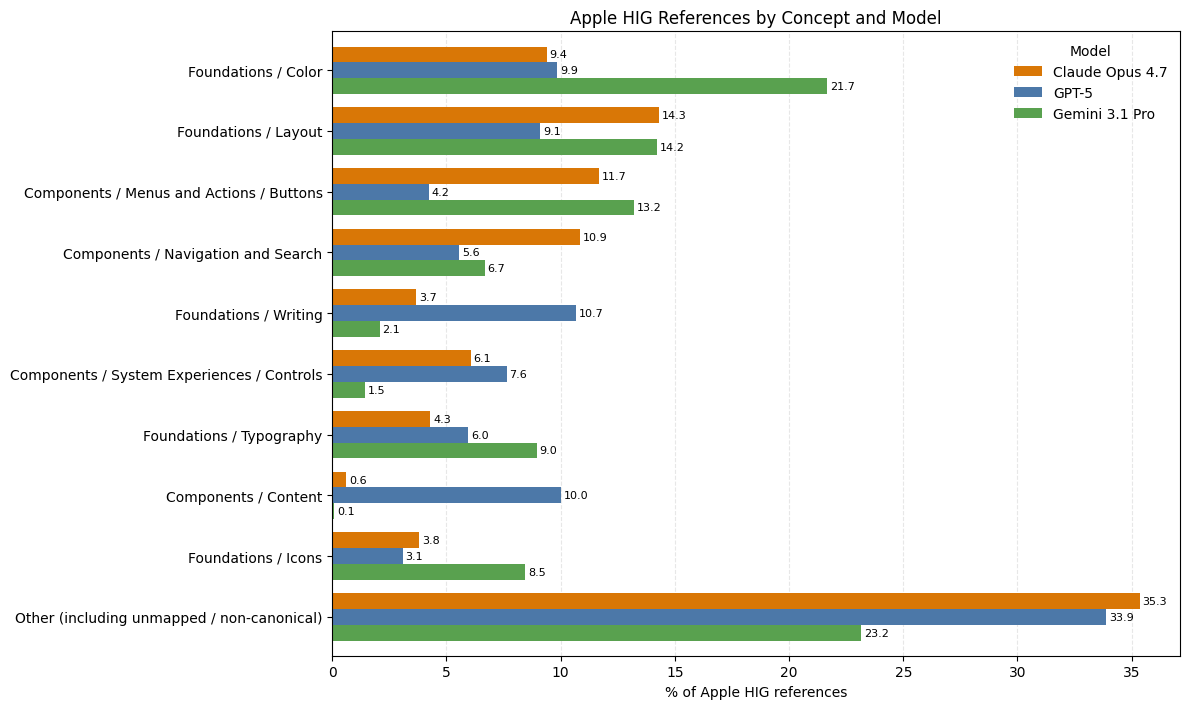

In [36]:
apple_top_k = 9
apple_other_label = "Other (including unmapped / non-canonical)"
apple_df["apple_concept_mapped"] = apple_df["category"].apply(
    lambda value: normalize_key(value) in APPLE_TOP_LOOKUP
)
apple_top_concepts = (
    apple_df.loc[apple_df["apple_concept_mapped"], "apple_concept"]
    .value_counts()
    .head(apple_top_k)
    .index
    .tolist()
)
apple_df["apple_plot_concept"] = apple_df["apple_concept"].where(
    apple_df["apple_concept_mapped"] & apple_df["apple_concept"].isin(apple_top_concepts),
    apple_other_label,
)
apple_plot_percent_df = ranked_reference_percentages(
    apple_df, "apple_plot_concept", "apple_concept"
)
apple_plot_order = [*apple_top_concepts, apple_other_label]
apple_plot_df = (
    apple_plot_percent_df
    .pivot(index="apple_concept", columns="model_name", values="pct_references")
    .reindex(index=apple_plot_order, columns=[MODEL_DISPLAY[model] for model in MODEL_ORDER])
    .fillna(0)
)

ax = apple_plot_df.plot.barh(
    figsize=(12, 7.2),
    width=0.78,
    color=[model_colors[column] for column in apple_plot_df.columns],
)
ax.invert_yaxis()
ax.set_title("Apple HIG References by Concept and Model")
ax.set_xlabel("% of Apple HIG references")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)
ax.legend(title="Model", frameon=False)
save_guideline_figure("guideline_apple_hig.png")


The Apple HIG concepts point to a more interface-component-oriented framing. Claude's largest displayed concepts are `Foundations / Layout` (14.30%), `Components / Menus and Actions / Buttons` (11.66%), and `Components / Navigation and Search` (10.87%), which fits a critique style focused on spatial structure, controls, and navigation. GPT-5 gives comparatively large shares to `Foundations / Writing` (10.67%), `Components / Content` (10.00%), `Foundations / Color` (9.86%), and `Foundations / Layout` (9.11%). Gemini is more visually concentrated: `Foundations / Color` accounts for 21.67% of its Apple HIG references, followed by layout (14.24%), buttons (13.23%), typography (8.96%), and icons (8.45%). The `Other` bin is a residual reporting category rather than a coherent design concept, so its size should not be interpreted as a single thematic focus.


### 10.2.3 CrowdCrit Category Distribution

CrowdCrit's noisier free-text labels are merged into broader focus groups using the documented keyword rules above. The figure includes every grouped reference, orders the substantive focus groups by their pooled frequency across all three models, and places `Other / specific critique labels` last. Each row contains one bar per model; percentages are calculated within each model's CrowdCrit references and sum to 100% before rounding.


In [37]:
crowdcrit_df = parsed_long_df.loc[parsed_long_df["source"].eq("CrowdCrit")].copy()
crowdcrit_category_percent_df = ranked_reference_percentages(
    crowdcrit_df,
    "category",
    "crowdcrit_category",
    top_n=top_n,
)

CROWDCRIT_FOCUS_PATTERNS = {
    "Color, Contrast & Legibility": r"contrast|color|legib",
    "Visual Hierarchy & Emphasis": r"hierarch|emphasis|weight",
    "Typography & Text": r"typograph|text|readab",
    "Layout, Spacing & Alignment": r"layout|space|align|proportion|size",
    "Labeling, Content & Information Clarity": r"label|content|inform|clarity",
    "Gestalt: Grouping & Proximity": r"group|proximit|gestalt|unity|organi|differentiat",
    "Affordance & Usability": r"afford|usab|button|ui element|principle",
    "Iconography & Imagery": r"icon|imag",
    "Consistency & Standards": r"consisten|style|aesthetic|visual design",
    "Clutter & Simplicity": r"clutter|noise|simplic|redund"
}

def crowdcrit_focus(value):
    key = normalize_key(value)
    for focus, pattern in CROWDCRIT_FOCUS_PATTERNS.items():
        if re.search(pattern, key):
            return focus
    return "Other / specific critique labels"

crowdcrit_df["crowdcrit_focus"] = crowdcrit_df["category"].apply(crowdcrit_focus)
crowdcrit_focus_percent_df = ranked_reference_percentages(
    crowdcrit_df,
    "crowdcrit_focus",
    "crowdcrit_focus",
)

# display_by_model(crowdcrit_category_percent_df.round(2))
# print("==========================\nCrowdCrit focus percentages by model:")
# display_by_model(crowdcrit_focus_percent_df.round(2))

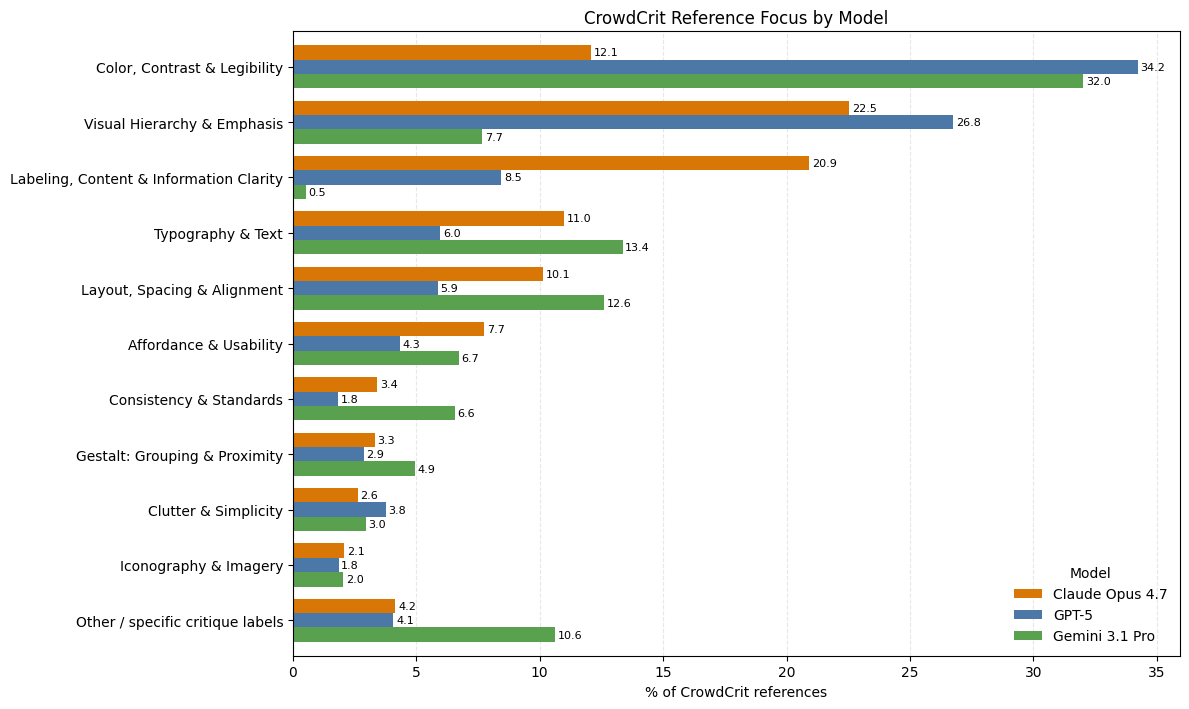

In [38]:
crowdcrit_other_label = "Other / specific critique labels"
crowdcrit_focus_order = (
    crowdcrit_df.loc[crowdcrit_df["crowdcrit_focus"].ne(crowdcrit_other_label), "crowdcrit_focus"]
    .value_counts()
    .index
    .tolist()
)
crowdcrit_focus_order.append(crowdcrit_other_label)
crowdcrit_focus_plot_df = (
    crowdcrit_focus_percent_df
    .pivot(index="crowdcrit_focus", columns="model_name", values="pct_references")
    .reindex(index=crowdcrit_focus_order, columns=[MODEL_DISPLAY[model] for model in MODEL_ORDER])
    .fillna(0)
)

ax = crowdcrit_focus_plot_df.plot.barh(
    figsize=(12, 7.2),
    width=0.78,
    color=[model_colors[column] for column in crowdcrit_focus_plot_df.columns],
)
ax.invert_yaxis()
ax.set_title("CrowdCrit Reference Focus by Model")
ax.set_xlabel("% of CrowdCrit references")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)
ax.legend(title="Model", frameon=False)
save_guideline_figure("guideline_crowdcrit.png")


CrowdCrit references make the visual emphasis clearest. After grouping similar free-text labels, `Color, Contrast & Legibility` is the largest focus group for GPT-5 (34.23%) and Gemini 3.1 Pro (32.01%), while Claude's largest group is `Visual Hierarchy & Emphasis` (22.54%). Claude also has a comparatively large `Labeling, Content & Information Clarity` share (20.92%), whereas GPT-5 and Gemini cite that focus much less often (8.45% and 0.52%). Gemini gives more weight to `Typography & Text` (13.36%) and `Layout, Spacing & Alignment` (12.59%) than GPT-5 (5.97% and 5.87%), while GPT-5 is more sharply concentrated in contrast/legibility and hierarchy. Overall, the CrowdCrit output shows that the LLM critiques are dominated by visible, screenshot-grounded properties: contrast, hierarchy, typography, layout, spacing, and affordance.

Taken together, these distributions suggest that guideline references are useful for describing each model's critique style, not just for validating that a reference was present. Claude appears broader and more content/navigation oriented, GPT-5 emphasizes standards, contrast, hierarchy, and control clarity, and Gemini leans most strongly toward visual presentation. This matters for interpreting the matching results: a model may disagree with an expert not because it misses usability problems entirely, but because it preferentially frames the screen through a different set of guideline concepts.


## 10.3 Summary

The guideline-reference analysis shows that the models consistently attach their critiques to recognizable usability frameworks, but the references also reveal different critique styles. Nielsen references emphasize broad usability principles, Apple HIG references translate many critiques into platform and component concepts, and CrowdCrit references make the visual focus of the critiques most explicit.

Across the three frameworks, the dominant pattern is that LLM critiques are strongly oriented toward visible, screenshot-grounded properties: contrast, visual hierarchy, typography, layout, spacing, navigation, controls, and affordance. This is useful for static UI critique because these properties are directly observable, but it also means that less visible issues such as error recovery, help documentation, workflow consequences, or interaction behavior appear much less often.

The models differ mainly in emphasis. Claude Opus 4.7 foregrounds system visibility and recognition in its Nielsen references, layout, buttons, and navigation in its Apple HIG references, and visual hierarchy and information clarity in its CrowdCrit references. GPT-5 emphasizes consistency and standards in Nielsen, writing and content alongside color, layout, and controls in Apple HIG, and is especially concentrated on contrast/legibility and visual hierarchy in CrowdCrit. Gemini 3.1 Pro also emphasizes consistency and standards in Nielsen, but its Apple HIG references are more visually concentrated around color, layout, buttons, typography, and icons; its CrowdCrit references similarly prioritize contrast/legibility, typography, and spacing/alignment.

For interpreting the matching results, these differences matter because disagreement with experts may reflect framing as much as detection quality. A model can identify a plausible usability issue while grounding it in a different guideline concept, at a different level of specificity, or around a different visible component. The guideline references should therefore be treated as evidence about each model's critique lens, not only as evidence that the model cited a source.


# 11. Qualitative Analysis

## 11.1 Analysis of Relation Accuracy

Review relation-label accuracy through stratified samples and manual coding results.

This section creates stratified expert-LLM issue-pair samples for manual qualitative review. The sample contains three examples per model-relation cell, for a total target of `3 models × 7 relations × 3 examples = 63` rows.

The sampling source is `expert_coverage_df`: one selected/best relation per expert comment, joined back to `metric_pairs_df` for the expert/LLM issue text, screen/task context, and optional automatic metrics. This keeps the qualitative examples aligned with the expert-comment coverage analysis.

### 11.1.1 Qualitative Sampling Setup

Define relation groups, display columns, export columns, and deterministic sampling helpers.

In [39]:
QUALITATIVE_EXAMPLES_DIR = TABLES_DIR / "qualitative_examples"
QUALITATIVE_EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

EXAMPLES_PER_MODEL_RELATION = 3

QUALITATIVE_RELATION_GROUPS = {
    "exact_and_llm_broader": ["exact_match", "llm_broader"],
    "human_broader_and_partial": ["human_broader", "partial_overlap"],
    "different_no_match_and_contradiction": ["related_but_different", "no_match", "contradiction"],
}

QUALITATIVE_DISPLAY_COLUMNS = [
    "screen_id",
    "screen_task_id",
    "app_category",
    "task",
    "relation",
    "expert_observed_issue",
    "llm_observed_issue",
]

QUALITATIVE_EXPORT_COLUMNS = [
    "model_short",
    "model_name",
    "pair_id",
    "app_category",
    "screen_id",
    "screen_task_id",
    "task",
    "relation",
    "confidence",
    "expert_comment_id",
    "expert_observed_issue",
    "expert_expected_standard",
    "expert_suggested_fix",
    "expert_bounding_box",
    "llm_comment_id",
    "llm_observed_issue",
    "llm_expected_standard",
    "llm_suggested_fix",
    "llm_guideline_reference",
    "cosine_similarity",
    "bertscore_f1",
    "llm_entails_expert_entailment",
    "llm_entails_expert_contradiction",
    "expert_entails_llm_entailment",
    "expert_entails_llm_contradiction",
]

QUALITATIVE_REVIEW_COLUMNS = [
    "manual_relation_correct",
    "same_ui_element",
    "same_usability_problem",
    "same_user_impact",
    "unsupported_or_hallucinated",
    "qualitative_notes",
]


def stratified_qualitative_examples(relations, seed=42, n=EXAMPLES_PER_MODEL_RELATION):
    left_cols = {"model_short", "model_name", "screen_id", "screen_task_id", "expert_comment_id", "llm_comment_id", "relation", "confidence"}
    lookup_cols = list(dict.fromkeys([
        *PAIR_KEYS,
        "screen_id",
        *[col for col in QUALITATIVE_EXPORT_COLUMNS if col not in left_cols],
    ]))
    lookup_cols = [col for col in lookup_cols if col in metric_pairs_df.columns]
    source_df = (
        expert_coverage_df.rename(columns={"best_relation": "relation", "best_confidence": "confidence"})
        .merge(metric_pairs_df[lookup_cols].drop_duplicates(PAIR_KEYS), on=PAIR_KEYS, how="left", validate="one_to_one")
    )
    source_df = source_df[source_df["relation"].isin(relations)].copy()
    source_df["model_short"] = pd.Categorical(source_df["model_short"], MODEL_ORDER, ordered=True)
    source_df["relation"] = pd.Categorical(source_df["relation"], RELATION_ORDER, ordered=True)

    sampled = []
    for i, (_, group_df) in enumerate(source_df.groupby(["model_short", "relation"], observed=True, sort=False)):
        sampled.append(group_df.sample(min(n, len(group_df)), random_state=seed + i))

    review_df = pd.concat(sampled, ignore_index=True) if sampled else source_df.head(0).copy()
    review_df = review_df.sort_values(["model_short", "relation", "screen_task_id"]).reset_index(drop=True)
    review_df = review_df[[col for col in QUALITATIVE_EXPORT_COLUMNS if col in review_df.columns]].copy()

    for col in QUALITATIVE_REVIEW_COLUMNS:
        review_df[col] = ""

    return review_df


def display_qualitative_examples_for_model(review_df, model_short, n_rows=None):
    model_df = review_df.loc[review_df["model_short"].eq(model_short), QUALITATIVE_DISPLAY_COLUMNS]
    if n_rows is not None:
        model_df = model_df.head(n_rows)
    display_df(model_df)



def save_qualitative_examples(review_df, filename):
    output_path = QUALITATIVE_EXAMPLES_DIR / filename
    review_df.to_csv(output_path, index=False)
    print(f"Saved {len(review_df):,} examples to {output_path}")


### 11.1.2 Exact Match and LLM Broader

Sample cases where the LLM issue fully covers the expert issue, either at the same specificity level or as a broader formulation.

In [40]:
display_model = "gpt5"
display_rows = None
qualitative_exact_llm_broader_df = stratified_qualitative_examples(QUALITATIVE_RELATION_GROUPS["exact_and_llm_broader"], seed=42)
qualitative_exact_llm_broader_display_df = display_qualitative_examples_for_model(qualitative_exact_llm_broader_df, display_model, n_rows=display_rows)


,screen_id,screen_task_id,app_category,task,relation,expert_observed_issue,llm_observed_issue


In [41]:
save_qualitative_examples(
    qualitative_exact_llm_broader_df,
    "qualitative_examples_exact_match_llm_broader.csv",
)

Saved 0 examples to /home/mkhalil/thesis/Project/code/results/critiques/analysis/tables/qualitative_examples/qualitative_examples_exact_match_llm_broader.csv


### 11.1.3 Human Broader and Partial Overlap

Sample cases where the LLM captures only part of the expert issue or overlaps with it without fully covering the expert's observation.

In [42]:
display_model = "gpt5"
display_rows = None
qualitative_human_broader_partial_df = stratified_qualitative_examples(QUALITATIVE_RELATION_GROUPS["human_broader_and_partial"], seed=42)
qualitative_human_broader_partial_display_df = display_qualitative_examples_for_model(qualitative_human_broader_partial_df, display_model, n_rows=display_rows)


,screen_id,screen_task_id,app_category,task,relation,expert_observed_issue,llm_observed_issue
3,13004,13004_T03,Education,Read the information about Natural Reader text...,partial_overlap,the information is not organized in a logical ...,"Content is presented as long, dense paragraphs..."
4,19192,19192_T02,Music & Audio,Select & set animal sound ringtone,partial_overlap,"the text is small and difficult to read, and t...","The screen uses a decorative, playful typeface..."
5,36475,36475_T03,Lifestyle,Manage the settings,partial_overlap,a check box icon is missing which hinders user...,"“Season,” “Shop Location,” and “Notification T..."


In [43]:
save_qualitative_examples(
    qualitative_human_broader_partial_df,
    "qualitative_examples_human_broader_partial_overlap.csv",
)


Saved 9 examples to /home/mkhalil/thesis/Project/code/results/critiques/analysis/tables/qualitative_examples/qualitative_examples_human_broader_partial_overlap.csv


### 11.1.4 Related But Different, No Match, and Contradiction

Sample cases where the LLM issue is related but different, has no labeled relation to the expert issue, or directly contradicts the expert issue. In the stored labels, the no-relation category is named `no_match`.

In [44]:
display_model = "gpt5"
display_rows = None
qualitative_different_no_match_contradiction_df = stratified_qualitative_examples(QUALITATIVE_RELATION_GROUPS["different_no_match_and_contradiction"], seed=42)
qualitative_different_no_match_contradiction_display_df = display_qualitative_examples_for_model(qualitative_different_no_match_contradiction_df, display_model, n_rows=display_rows)


,screen_id,screen_task_id,app_category,task,relation,expert_observed_issue,llm_observed_issue
9,34573,34573_T02,Lifestyle,Write feedback and send it.,contradiction,the element on the screen appears non-clickabl...,The SEND action appears tappable even when the...
10,42264,42264_T01,Lifestyle,Choose Your Answer by Clicking Button.,contradiction,"the design lacks a back button, which can be f...",An in-app Back button duplicates the OS back n...
11,62580,62580_T02,Communication,"Click the ""Fix"" button to remove the 2 detecte...",contradiction,the Upgrade button is not visually prominent.,The “UPGRADE” button uses the same bright acce...
12,16725,16725_T01,Maps & Navigation,Create a new account or login with the existin...,related_but_different,the form is not visually appealing because it ...,A large custom circular “X” clear icon appears...
13,24805,24805_T02,Comics,Read the story now,related_but_different,This font type choice makes the text difficult...,The green title and orange 'MORAL' label sit o...
14,62268,62268_T01,Sports,Enter your details for login / create account.,related_but_different,"buttons are too congested, leading to difficul...",The Login button is centered and noticeably na...
15,40995,40995_T01,Shopping,Browse the latest auto news.,no_match,the app name is not visually prominent.,Large 16:9 thumbnails and generous vertical pa...
16,70172,70172_T02,Social,Review your likes.,no_match,"the ""Play Match now"" button the color scheme i...","The secondary tab is labeled “Glances,” which ..."
17,72194,72194_T01,Travel & Local,"Click ""Next"" to view the Yellowbook or click ""...",no_match,the app name's first letter is not capitalized.,The NEXT button sits very close to the Android...


In [45]:
save_qualitative_examples(
    qualitative_different_no_match_contradiction_df,
    "qualitative_examples_related_different_no_match_contradiction.csv",
)

Saved 27 examples to /home/mkhalil/thesis/Project/code/results/critiques/analysis/tables/qualitative_examples/qualitative_examples_related_different_no_match_contradiction.csv


### 11.1.5 Combined Qualitative Sample

Save the full qualitative sample across all seven relation labels for convenience.

In [46]:
qualitative_examples_all_df = pd.concat(
    [
        qualitative_exact_llm_broader_df,
        qualitative_human_broader_partial_df,
        qualitative_different_no_match_contradiction_df,
    ],
    ignore_index=True,
)

qualitative_examples_all_path = QUALITATIVE_EXAMPLES_DIR / "qualitative_examples_all_relations.csv"
qualitative_examples_all_df.to_csv(qualitative_examples_all_path, index=False)
print(f"Saved {len(qualitative_examples_all_df):,} examples to {qualitative_examples_all_path}")

qualitative_counts_df = (
    qualitative_examples_all_df.groupby(["model_name", "relation"], observed=False)
    .size()
    .reset_index(name="examples")
)
display_df(qualitative_counts_df)

Saved 36 examples to /home/mkhalil/thesis/Project/code/results/critiques/analysis/tables/qualitative_examples/qualitative_examples_all_relations.csv


,model_name,relation,examples
0,Claude Opus 4.7,equivalent,0
1,Claude Opus 4.7,B_broader,0
2,Claude Opus 4.7,A_broader,0
3,Claude Opus 4.7,partial_overlap,3
4,Claude Opus 4.7,contradiction,3
5,Claude Opus 4.7,related_but_different,3
6,Claude Opus 4.7,no_match,3
7,GPT-5,equivalent,0
8,GPT-5,B_broader,0
9,GPT-5,A_broader,0


### 11.1.6 Manual Coding Procedure

I manually reviewed the 63 sampled expert-centered pairs (`3 models x 7 relations x 3 examples`) by comparing the expert issue, LLM issue, relation label, task context, and screenshot. Each pair was coded for whether the relation label was defensible, whether both comments referred to the same UI element, usability problem, and user impact, and whether the LLM issue was grounded in visible screen evidence.

The coded review table was saved as `qualitative_examples_manual_coding.csv` in the qualitative examples folder. The coding fields were: `relation_assessment`, `same_ui_element`, `same_usability_problem`, `same_user_impact`, `grounded_in_screen`, `unsupported_or_hallucinated`, `vague_or_generic`, `actionable`, `overstated`, and `coding_note`.

In [47]:
from IPython.display import Markdown, display
import pandas as pd


def explore_example(
    explore_model="gpt5",
    explore_relation="exact_match",
    explore_position=0,
    explore_screen_task_id=None,
    explore_pair_id=None,
):
    manual_coding_path = (
        QUALITATIVE_EXAMPLES_DIR / "qualitative_examples_manual_coding.csv"
    )
    manual_coding_df = pd.read_csv(manual_coding_path)

    filtered_df = manual_coding_df.copy()

    if explore_model is not None:
        model_mask = (
            filtered_df["model_short"].eq(explore_model)
            | filtered_df["model_name"].eq(explore_model)
        )
        filtered_df = filtered_df[model_mask]

    if explore_relation is not None:
        filtered_df = filtered_df[
            filtered_df["relation"].eq(explore_relation)
        ]

    if explore_screen_task_id is not None:
        filtered_df = filtered_df[
            filtered_df["screen_task_id"].eq(explore_screen_task_id)
        ]

    if explore_pair_id is not None:
        filtered_df = filtered_df[
            filtered_df["pair_id"].eq(explore_pair_id)
        ]

    filtered_df = (
        filtered_df
        .sort_values(
            ["model_short", "relation", "screen_task_id", "pair_id"]
        )
        .reset_index(drop=True)
    )

    if filtered_df.empty:
        raise ValueError("No examples match the current filters.")

    if explore_position >= len(filtered_df):
        raise IndexError(
            f"explore_position={explore_position} "
            f"but only {len(filtered_df)} examples match."
        )

    row = filtered_df.iloc[explore_position]

    # Header
    print(
        f"Showing {explore_position + 1} of {len(filtered_df)} filtered examples"
    )
    print(
        f"Model: {row['model_name']} | "
        f"Relation: {row['relation']} | "
        f"Pair: {row['pair_id']} | "
        f"Screen task: {row['screen_task_id']}"
    )

    print("\nTask:")
    print(row["task"])
    
    print("\nExpert observed issue:")
    print(row["expert_observed_issue"])

    print("\nLLM observed issue:")
    print(row["llm_observed_issue"])

    print("\nCoding Note:")
    print(row["coding_note"])

    print()
    show_screen(screen_id=row["screen_id"], width=320)

    # Remaining metadata
    review_columns = [
        "model_name",
        "relation",
        "confidence",
        "app_category",
        "screen_id",
        "screen_task_id",
        "task",
        "relation_assessment",
        "same_ui_element",
        "same_usability_problem",
        "same_user_impact",
        "grounded_in_screen",
        "unsupported_or_hallucinated",
        "vague_or_generic",
        "actionable",
        "overstated",
        "coding_note",
    ]

    review_columns = [
        col
        for col in review_columns
        if col in filtered_df.columns
    ]

    display(row[review_columns].to_frame(name="value"))


Showing 1 of 3 filtered examples
Model: Claude Opus 4.7 | Relation: related_but_different | Pair: P_00029304 | Screen task: 41870_T01

Task:
Click on "I agree" to accept Google Fit's Terms of Service and Privacy Policy.

Expert observed issue:
text is difficult to read due to its small size.

LLM observed issue:
The 'I AGREE' and 'NO, THANKS' text labels are positioned at the very bottom edge and lack visible touch target containers, making it unclear how large the tappable region is.

Coding Note:
Contradiction is not correct. Better: partial_overlap. The expert says there is enough white space to adjust elements; the LLM says the dropdown is too close to the navigation links. Both are about spacing, and both can be true.



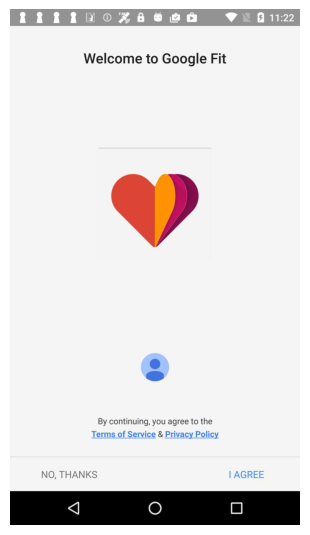

,value
model_name,Claude Opus 4.7
relation,related_but_different
confidence,0.8
app_category,Health & Fitness
screen_id,41870
screen_task_id,41870_T01
task,"Click on ""I agree"" to accept Google Fit's Term..."
relation_assessment,wrong
same_ui_element,partial
same_usability_problem,partial


In [48]:
explore_model = "claude4_7"
explore_relation = "related_but_different"
explore_position = 0
explore_screen_task_id = None
explore_pair_id = None

explore_example(
    explore_model,
    explore_relation,
    explore_position,
    explore_screen_task_id,
    explore_pair_id
)

In [49]:
new_relation_assessment = "wrong"
new_same_ui_element = "partial"
new_same_usability_problem = "partial"
new_same_user_impact = "partial"
new_grounded_in_screen = "yes"
new_unsupported_or_hallucinated = "no"
new_vague_or_generic = "no"
new_actionable = "yes"
new_overstated = "no"
new_coding_note = "Contradiction is not correct. Better: partial_overlap. The expert says there is enough white space to adjust elements; the LLM says the dropdown is too close to the navigation links. Both are about spacing, and both can be true."

manual_coding_path = QUALITATIVE_EXAMPLES_DIR / "qualitative_examples_manual_coding.csv"
manual_coding_df = pd.read_csv(manual_coding_path)

filtered_idx = manual_coding_df.index

if explore_model is not None:
    filtered_idx = filtered_idx[
        manual_coding_df.loc[filtered_idx, "model_short"].eq(explore_model)
        | manual_coding_df.loc[filtered_idx, "model_name"].eq(explore_model)
    ]

if explore_relation is not None:
    filtered_idx = filtered_idx[
        manual_coding_df.loc[filtered_idx, "relation"].eq(explore_relation)
    ]

if explore_screen_task_id is not None:
    filtered_idx = filtered_idx[
        manual_coding_df.loc[filtered_idx, "screen_task_id"].eq(explore_screen_task_id)
    ]

if explore_pair_id is not None:
    filtered_idx = filtered_idx[
        manual_coding_df.loc[filtered_idx, "pair_id"].eq(explore_pair_id)
    ]

filtered_idx = manual_coding_df.loc[filtered_idx].sort_values(
    ["model_short", "relation", "screen_task_id", "pair_id"]
).index

if len(filtered_idx) == 0:
    raise ValueError("No examples match the current filters.")

if explore_position >= len(filtered_idx):
    raise IndexError(f"explore_position={explore_position}, but only {len(filtered_idx)} examples match.")

target_idx = filtered_idx[explore_position]
manual_coding_df.loc[target_idx, [
    "relation_assessment",
    "same_ui_element",
    "same_usability_problem",
    "same_user_impact",
    "grounded_in_screen",
    "unsupported_or_hallucinated",
    "vague_or_generic",
    "actionable",
    "overstated",
    "coding_note"
]] = [
    new_relation_assessment,
    new_same_ui_element,
    new_same_usability_problem,
    new_same_user_impact,
    new_grounded_in_screen,
    new_unsupported_or_hallucinated,
    new_vague_or_generic,
    new_actionable,
    new_overstated,
    new_coding_note
]
manual_coding_df.to_csv(manual_coding_path, index=False)

print(f"Updated coding_note for row index {target_idx}")
print(manual_coding_df.loc[target_idx, ["model_name", "relation", "screen_task_id", "pair_id", "coding_note"]])

Updated coding_note for row index 39
model_name                                          Claude Opus 4.7
relation                                      related_but_different
screen_task_id                                            41870_T01
pair_id                                                  P_00029304
coding_note       Contradiction is not correct. Better: partial_...
Name: 39, dtype: str


### 11.1.7 Display All Paired Comments with Coded Labels and Notes

In [50]:
manual_coding_path = QUALITATIVE_EXAMPLES_DIR / "qualitative_examples_manual_coding.csv"
manual_coding_df = pd.read_csv(manual_coding_path)

coded_pair_columns = [
    "model_name",
    "relation",
    "relation_assessment",
    "same_ui_element",
    "same_usability_problem",
    "same_user_impact",
    "grounded_in_screen",
    "unsupported_or_hallucinated",
    "vague_or_generic",
    "actionable",
    "overstated",
    "app_category",
    "screen_id",
    "screen_task_id",
    "task",
    "expert_observed_issue",
    "llm_observed_issue",
    "coding_note",
]

coded_pair_sorted_df = manual_coding_df.copy()
coded_pair_sorted_df["model_short"] = pd.Categorical(
    coded_pair_sorted_df["model_short"], MODEL_ORDER, ordered=True
)
coded_pair_sorted_df["relation"] = pd.Categorical(
    coded_pair_sorted_df["relation"], RELATION_ORDER, ordered=True
)
coded_pair_sorted_df = coded_pair_sorted_df.sort_values(
    ["model_short", "relation", "screen_task_id", "pair_id"]
).reset_index(drop=True)

coded_pair_count_df = (
    coded_pair_sorted_df.groupby(["model_short", "model_name", "relation"], observed=True, sort=False)
    .size()
    .reset_index(name="coded_pairs")
    .drop(columns="model_short")
)

coded_pair_display_df = coded_pair_sorted_df[
    [col for col in coded_pair_columns if col in coded_pair_sorted_df.columns]
]

display_df(coded_pair_count_df)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", 220,
):
    display_df(coded_pair_display_df)


/tmp/ipykernel_135384/1346144017.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  coded_pair_sorted_df["relation"] = pd.Categorical(


,model_name,relation,coded_pairs
0,Claude Opus 4.7,partial_overlap,3
1,Claude Opus 4.7,contradiction,3
2,Claude Opus 4.7,related_but_different,3
3,Claude Opus 4.7,no_match,3
4,GPT-5,partial_overlap,3
5,GPT-5,contradiction,3
6,GPT-5,related_but_different,3
7,GPT-5,no_match,3
8,Gemini 3.1 Pro,partial_overlap,3
9,Gemini 3.1 Pro,contradiction,3


,model_name,relation,relation_assessment,same_ui_element,same_usability_problem,same_user_impact,grounded_in_screen,unsupported_or_hallucinated,vague_or_generic,actionable,overstated,app_category,screen_id,screen_task_id,task,expert_observed_issue,llm_observed_issue,coding_note
0,Claude Opus 4.7,partial_overlap,too_generous,partial,partial,yes,yes,no,no,yes,no,Maps & Navigation,1693,1693_T01,View nearby gas stations,labels are not consistently aligned.,"All list items use the same dense block of text with multiple lines (address, phone, fuel info, attribution), creating visual clutter and making it hard to distinguish key information at a glance.","Both relate to list readability, but LLM does not address alignment."
1,Claude Opus 4.7,partial_overlap,correct,yes,partial,yes,yes,no,no,yes,no,Auto & Vehicles,3297,3297_T02,Choose number of years for your car,the texts colors are too light and the fonts are too small.,"The year list items are styled in low-contrast gray text with thin dividers and no clear affordance beyond a small chevron, making the selectable nature of each row visually weak.","Both mention low-contrast/light text, but the expert also mentions small fonts, while the LLM adds a separate issue about weak selectable affordance."
2,Claude Opus 4.7,partial_overlap,correct,yes,partial,yes,yes,no,no,yes,no,Health & Fitness,59382,59382_T02,"Click on ""Work"" or ""Reset"", or go to Settings.","the font is too small and the text is too dense, making it difficult to read.","'Round Time' and 'Rest Time' labels along with their values (03:00 / 01:00) appear in low contrast gray on a black background, making them hard to read.","Both identify readability problems, but the expert blames small/dense text overall, while the LLM focuses specifically on low-contrast gray timing labels."
3,Claude Opus 4.7,contradiction,correct,yes,yes,yes,yes,no,no,yes,no,NaN,36822,36822_T01,"Read article on ""Flan's Mod 5.3 Rank Update"" published by Minecraft Forum",there is no button on the page for navigating further.,"The pagination controls ('<<', '<', '1 ▾', '>', '>>') use small text symbols with minimal padding and unclear tappable area, making them hard to use on a touch screen.",Expert might be wrong here saying no navigation button; LLM identifies visible pagination controls.
4,Claude Opus 4.7,contradiction,correct,yes,yes,yes,yes,partial,no,yes,no,Travel & Local,49516,49516_T03,Manage user's account dashboard,"the ""Edit profile"" button shares the same background as the layout, making it challenging for users to identify and interact with it.","The 'Edit Profile' button is prominent but profile fields are not previewed (e.g., email, phone), and only the name is displayed, making it unclear what editing entails.","Direct opposition on Edit Profile prominence. LLM says it's prominent, while in fact its color is very similar to the background."
5,Claude Opus 4.7,contradiction,correct,yes,yes,yes,yes,yes,no,yes,no,Sports,7836,7836_T02,Select an option to explore,there is no consistency in texts. The font type/size/color/weight of all texts are different from each other in the whole design.,"All menu items (Home, Events, Rankings, Fantasy, WSL Store, Settings, Feedback, About This App) share nearly identical typographic styling, making it difficult to identify which are primary exploration destinations v...","LLM is incorrect. Setting, Feedback, and About, has different size and weight."
6,Claude Opus 4.7,related_but_different,wrong,partial,partial,partial,yes,no,no,yes,no,Health & Fitness,41870,41870_T01,"Click on ""I agree"" to accept Google Fit's Terms of Service and Privacy Policy.",text is difficult to read due to its small size.,"The 'I AGREE' and 'NO, THANKS' text labels are positioned at the very bottom edge and lack visible touch target containers, making it unclear how large the tappable region is.","Contradiction is not correct. Better: partial_overlap. The expert says there is enough white space to adjust elements; the LLM says

### 11.1.8 Overall Coding Summary

In [51]:
manual_coding_df = pd.read_csv(QUALITATIVE_EXAMPLES_DIR / "qualitative_examples_manual_coding.csv")

print(f"Coded pairs: {len(manual_coding_df)}")
display(manual_coding_df["relation_assessment"].value_counts().rename_axis("assessment").reset_index(name="pairs"))

display(manual_coding_df[[
    "same_ui_element",
    "same_usability_problem",
    "same_user_impact",
    "grounded_in_screen",
    "unsupported_or_hallucinated",
    "vague_or_generic",
    "actionable",
    "overstated",
]].apply(pd.Series.value_counts).fillna(0).astype(int))

display(pd.crosstab(manual_coding_df["relation"], manual_coding_df["relation_assessment"]))

Coded pairs: 63


,assessment,pairs
0,correct,49
1,wrong,10
2,too_generous,3
3,partial,1


,same_ui_element,same_usability_problem,same_user_impact,grounded_in_screen,unsupported_or_hallucinated,vague_or_generic,actionable,overstated
no,10,12,4,0,59,63,0,62
partial,19,16,11,1,1,0,0,0
yes,34,35,48,62,3,0,63,1


relation_assessment,correct,partial,too_generous,wrong
relation,,,,
contradiction,3,1,0,5
exact_match,6,0,1,2
human_broader,8,0,1,0
llm_broader,8,0,0,1
no_match,9,0,0,0
partial_overlap,7,0,1,1
related_but_different,8,0,0,1


#### 11.1.8 Summary
Most sampled labels were defensible, but the audit shows that the matching labels should be interpreted as semantic alignment categories rather than proof that the expert and LLM always identified the same concrete issue.

| Manual assessment | Pairs |
|---|---:|
| Correct | 50 |
| Too generous | 3 |
| Wrong | 9 |
| Partial | 1 |

Across the 63 coded pairs, 34 referred to the same UI element, 19 partially overlapped on the element, and 10 referred to different elements. Agreement was slightly stronger at the usability-problem level: 35 pairs shared the same problem, 16 partially overlapped, and 12 did not share the same problem. User impact aligned most often, with 49 pairs sharing the same impact, 10 partially overlapping, and 4 differing.

The LLM critiques were usually usable as critiques even when the relation label was imperfect: 62 of 63 were grounded in the screen, all 63 were actionable, none were coded as vague or generic, and only 3 were unsupported or hallucinated, with 1 additional partial unsupported case.

Notes:
- llms writes detailed comments
- most of it is about visuals
- llms focus on atomic things, whereas human talks about multiple things or generalize rather than be specific


## 11.2 General Sample Analysis

In [36]:
def stratified_sample_pairs(df, n=15, seed=42):
    df = df.dropna(subset=["llm_observed_issue"]).drop_duplicates().copy()
    if df.empty:
        return df

    df["app_category"] = df["app_category"].fillna("Unknown")
    n = min(n, len(df))
    strata = df["app_category"].rename("_stratum")

    base_sample_df = df.groupby(strata, group_keys=False).apply(
        lambda x: x.sample(1, random_state=seed)
    )
    base_sample_df = base_sample_df.sample(frac=1, random_state=seed).head(n)

    remaining_n = n - len(base_sample_df)
    if remaining_n > 0:
        remaining_df = df.drop(index=base_sample_df.index)
        extra_sample_df = remaining_df.sample(
            n=min(remaining_n, len(remaining_df)),
            random_state=seed,
        )
        base_sample_df = pd.concat([base_sample_df, extra_sample_df], ignore_index=False)

    return base_sample_df.sample(frac=1, random_state=seed).reset_index(drop=True)


def print_sample_pairs(sample_model, relations, n=15, seed=42, show_expert=True, show_suggested_fix=True):
    cols = [
        "app_category", "screen_task_id", "task", "relation",
        "expert_observed_issue", "llm_observed_issue", "llm_suggested_fix",
    ]

    for relation in relations:
        source_df = metric_pairs_df[
            (metric_pairs_df["model_short"] == sample_model)
            & (metric_pairs_df["relation"] == relation)
        ][cols]
        sample_df = stratified_sample_pairs(source_df, n=n, seed=seed)

        print(f"\n{'=' * 90}")
        print(f"Model: {sample_model} | Relation: {relation} | Sampled: {len(sample_df)}")
        print()

        for i, row in enumerate(sample_df.itertuples(index=False), start=1):
            print(f"{i}. App category: {row.app_category}")
            print(f"Screen task: {row.screen_task_id}")
            print(f"Task: {row.task}")
            if show_expert:
                print(f"Expert issue: {row.expert_observed_issue}")
            print(f"LLM issue: {row.llm_observed_issue}")
            if show_suggested_fix:
                print(f"Suggested fix: {row.llm_suggested_fix}")
            print()


In [53]:
for sample_model in MODEL_ORDER:
    print_sample_pairs(
        sample_model,
        relations=["exact_match"],
        n=30,
        seed=42,
        show_expert = False
    )


Model: claude4_7 | Relation: exact_match | Sampled: 0


Model: gpt5 | Relation: exact_match | Sampled: 0


Model: gemini3_1pro | Relation: exact_match | Sampled: 0



## 11.3 Unsupported Comment Analysis
- determine whether unsupported LLM comments are legitimate new observations
- identify hallucinations
- distinguish vague-but-valid comments from unsupported claims
- check whether expert annotations missed something

In [201]:
REVIEW_DIR = TABLES_DIR / "qualitative_examples"
REVIEW_DIR.mkdir(parents=True, exist_ok=True)
UNSUPPORTED_SAMPLE_PATH = REVIEW_DIR / "unsupported_comment_review_sample_old_pairs.csv"
CONTRADICTION_SAMPLE_PATH = REVIEW_DIR / "contradiction_review_sample.csv"
PAIR_REVIEW_LABELS_PATH = REVIEW_DIR / "pair_review_labels.csv"


def load_or_create_pair_review_sample(relation, n=30, seed=42):
    sample_path = UNSUPPORTED_SAMPLE_PATH if relation == "no_match" else CONTRADICTION_SAMPLE_PATH
    if sample_path.exists():
        return pd.read_csv(sample_path)

    if relation == "no_match":
        raise FileNotFoundError(f"The frozen Section 11.3 sample is missing: {sample_path}")

    cols = [
        "model_short", "model_name", "pair_id", "screen_task_id",
        "expert_comment_id", "llm_comment_id", "screen_id", "app_category",
        "task", "relation", "confidence", "expert_observed_issue",
        "expert_bounding_box", "llm_observed_issue",
    ]
    source_df = metric_pairs_df[metric_pairs_df["relation"].eq(relation)][cols].copy()
    samples = []
    for model in MODEL_ORDER:
        model_sample_df = stratified_sample_pairs(
            source_df[source_df["model_short"].eq(model)], n=n, seed=seed
        )
        model_sample_df.insert(2, "sample_index", range(len(model_sample_df)))
        samples.append(model_sample_df)
    sample_df = pd.concat(samples, ignore_index=True)
    sample_df.to_csv(sample_path, index=False)
    print(f"Saved {len(sample_df):,} sampled pairs to {sample_path}")
    return sample_df


def add_expert_bounding_boxes(sample_df):
    if "expert_bounding_box" in sample_df and sample_df["expert_bounding_box"].notna().all():
        return sample_df

    result_df = sample_df.drop(columns="expert_bounding_box", errors="ignore").copy()
    result_df["_expert_id_norm"] = result_df["expert_comment_id"].astype("string").str.removeprefix("H_")
    bbox_lookup_df = metric_pairs_df[[
        "model_short", "screen_task_id", "expert_comment_id", "expert_bounding_box"
    ]].copy()
    bbox_lookup_df["_expert_id_norm"] = bbox_lookup_df["expert_comment_id"].astype("string").str.removeprefix("H_")
    bbox_lookup_df = bbox_lookup_df.drop(columns="expert_comment_id").drop_duplicates(
        ["model_short", "screen_task_id", "_expert_id_norm"]
    )
    return result_df.merge(
        bbox_lookup_df,
        on=["model_short", "screen_task_id", "_expert_id_norm"],
        how="left",
        validate="many_to_one",
    ).drop(columns="_expert_id_norm")


def save_current_pair_review(section, label, note=""):
    row = current_review_row
    record = pd.DataFrame([{
        "section": str(section),
        "model_short": row["model_short"],
        "sample_index": int(row["sample_index"]),
        "screen_task_id": row["screen_task_id"],
        "expert_comment_id": row.get("expert_comment_id"),
        "llm_comment_id": row["llm_comment_id"],
        "relation": row["relation"],
        "label": label,
        "note": note,
    }])
    key_cols = ["section", "model_short", "sample_index"]
    if PAIR_REVIEW_LABELS_PATH.exists():
        saved_df = pd.read_csv(PAIR_REVIEW_LABELS_PATH, dtype={"section": str})
        missing_key_cols = [col for col in key_cols if col not in saved_df.columns]
        if missing_key_cols:
            raise ValueError(f"Existing review file is missing columns: {missing_key_cols}")
        same_sample = pd.Series(True, index=saved_df.index)
        for col in key_cols:
            same_sample &= saved_df[col].eq(record.iloc[0][col])
        saved_df = saved_df.loc[~same_sample]
        record = pd.concat([saved_df, record], ignore_index=True)
    record = record.drop_duplicates(key_cols, keep="last")
    record = record.sort_values(key_cols).reset_index(drop=True)
    record.to_csv(PAIR_REVIEW_LABELS_PATH, index=False)
    section_rows = record[record["section"].eq(str(section))]
    print(f"Saved {len(section_rows)}/90 reviews for Section {section} to {PAIR_REVIEW_LABELS_PATH}")


def show_comment_for_review(model="claude4_7", index=0, relation="no_match", n=30, seed=42):
    global current_comment_key, current_review_key, current_review_row
    sample_df = add_expert_bounding_boxes(load_or_create_pair_review_sample(relation, n=n, seed=seed))
    model_sample_df = sample_df[sample_df["model_short"].eq(model)].sort_values("sample_index")
    if not 0 <= index < len(model_sample_df):
        raise IndexError(f"index must be between 0 and {len(model_sample_df) - 1}")
    row = model_sample_df.iloc[index]
    current_review_row = row
    current_comment_key = (row["model_short"], row["screen_task_id"], row["llm_comment_id"])
    current_review_key = (row["model_short"], relation, row["screen_task_id"], row.get("expert_comment_id"), row["llm_comment_id"])

    print(f"{index + 1}/{len(model_sample_df)} {relation} - {model}")
    print("Pair IDs:", row.get("expert_comment_id"), "|", row["llm_comment_id"])
    print("Task:", row["task"])
    if relation == "contradiction":
        print("Expert comment:", row["expert_observed_issue"])
    print("LLM comment:", row["llm_observed_issue"])
    expert_bbox = row.get("expert_bounding_box")
    show_screen(
        screen_id=row["screen_id"],
        bboxes=None if pd.isna(expert_bbox) else [expert_bbox],
        labels=None if pd.isna(expert_bbox) else ["Expert comment"],
        colors=["tab:red"],
        width=250,
    )


30/30 no_match - gemini3_1pro
Task: Select from options shown for prognosis
LLM comment: The menu items are center-aligned, creating a ragged left edge that makes the list harder to scan quickly compared to a standard left-aligned layout.


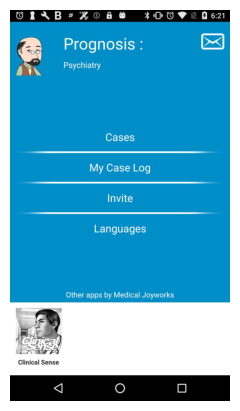

In [55]:
show_comment_for_review("gemini3_1pro", 29
                        
                        , relation="no_match")  # claude7_4 | gpt5 | gemini3_1pro

In [56]:
hallucination_label = 0  # 1 = hallucination, 0 = not hallucination
hallucination_note = ""
save_current_pair_review("11.3", hallucination_label, hallucination_note)

## 11.4 Contradiction Analysis
Focus on:
- true contradiction
- LLM wrong
- expert wrong or incomplete
- both valid under different interpretations
- ambiguity, missing context, or relation extraction issue

18/18 contradiction - gemini3_1pro
Pair IDs: 45798_T02_003 | L_gemini3_1pro_45798_T02_001
Task: Click "check update" to check/update the latest app version
Expert comment: there is no button on the page for navigating further.
LLM comment: The text directs the user to manually navigate to 'Setting -> Device Info' to perform the update, while a 'Check update' button is simultaneously offered directly below, creating ambiguity about the correct path to complete the task.


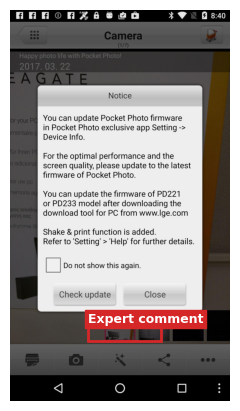

In [240]:
show_comment_for_review("gemini3_1pro", 17, relation="contradiction")

In [238]:
contradiction_score = 0  # 0 = no, 1 = partial, 2 = yes
# contradiction_comment = "Different framing or interpretation"
contradiction_comment = "Different issues or UI elements"
# contradiction_comment = "True contradictions: model favored"
# contradiction_comment = "True contradictions: human favored"
contradiction_comment = "Ambiguity in human annotation"
# contradiction_comment = "Ambiguity in screen"

save_current_pair_review("11.4", contradiction_score, contradiction_comment)

Saved 78/90 reviews for Section 11.4 to /home/mkhalil/thesis/Project/code/results/critiques/analysis/tables/qualitative_examples/pair_review_labels.csv


## 11.5 Unmatched Expert Comment Analysis

Examine expert comments whose best relation is only `no_match` / `no_relation` or `related_but_different`, including the expert comments that were not matched by all three models.

In [37]:
UNMATCHED_EXPERT_RELATIONS = ["no_match", "no_relation", "related_but_different"]


def build_unmatched_expert_comments(relations=UNMATCHED_EXPERT_RELATIONS):
    relations = [relation for relation in relations if relation in set(expert_coverage_df["best_relation"].dropna())]
    unmatched_by_model_df = expert_coverage_df[expert_coverage_df["best_relation"].isin(relations)].copy()

    counts_df = (
        unmatched_by_model_df.groupby(["model_short", "model_name", "best_relation"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=relations, fill_value=0)
    )
    counts_df["not_matched"] = counts_df.sum(axis=1)
    counts_df["expert_comments"] = expert_coverage_df.groupby(["model_short", "model_name"], observed=True).size()
    counts_df["not_matched_pct"] = (counts_df["not_matched"] / counts_df["expert_comments"] * 100).round(1)
    counts_df = counts_df.reset_index()
    counts_df["model_short"] = pd.Categorical(counts_df["model_short"], MODEL_ORDER, ordered=True)
    counts_df = counts_df.sort_values("model_short").reset_index(drop=True)

    all_models_df = (
        unmatched_by_model_df.groupby(["screen_task_id", "expert_comment_id"], as_index=False)
        .agg(models_not_matched=("model_short", "nunique"))
    )
    all_models_df = all_models_df[all_models_df["models_not_matched"].eq(len(MODEL_ORDER))]

    expert_cols = ["screen_task_id", "expert_comment_id", "screen_id", "app_category", "task", "expert_observed_issue", "expert_bounding_box"]
    all_models_df = all_models_df.merge(
        metric_pairs_df[expert_cols].drop_duplicates(["screen_task_id", "expert_comment_id"]),
        on=["screen_task_id", "expert_comment_id"],
        how="left",
    ).sort_values(["app_category", "screen_task_id", "expert_comment_id"]).reset_index(drop=True)

    return counts_df, all_models_df, unmatched_by_model_df


def display_unmatched_expert_comment_review(comments_df, limit=None):
    rows = comments_df.head(limit) if limit else comments_df
    for i, row in enumerate(rows.itertuples(index=False), start=1):
        print("=" * 100)
        print(f"{i}. {row.app_category} | screen_id={row.screen_id} | screen_task_id={row.screen_task_id} | expert_comment_id={row.expert_comment_id}")
        print(f"Task: {row.task}")
        print(f"Expert comment: {row.expert_observed_issue}")

        for model in MODEL_ORDER:
            model_df = metric_pairs_df[
                metric_pairs_df["model_short"].eq(model)
                & metric_pairs_df["screen_task_id"].eq(row.screen_task_id)
                & metric_pairs_df["expert_comment_id"].eq(row.expert_comment_id)
            ].copy()
            model_df["relation_rank"] = model_df["relation"].map(RELATION_RANK)
            model_df = model_df.sort_values(["relation_rank", "confidence"], ascending=[True, False])

            print(f"\n{MODEL_DISPLAY.get(model, model)}")
            for j, llm_row in enumerate(model_df.drop_duplicates("llm_comment_id").itertuples(index=False), start=1):
                print(f"  {j}. [{llm_row.relation}, confidence={llm_row.confidence:.2f}] {llm_row.llm_observed_issue}")
        print()


In [38]:
unmatched_expert_counts_df, unmatched_by_all_models_df, unmatched_expert_by_model_df = build_unmatched_expert_comments()

print("Expert comments not matched per model")
display_df(unmatched_expert_counts_df)

print(f"Expert comments not matched by all three models: {len(unmatched_by_all_models_df):,}")
display_df(unmatched_by_all_models_df[[
    "screen_id", "screen_task_id", "app_category", "expert_comment_id", "expert_observed_issue"
]])


Expert comments not matched per model


best_relation,model_name,no_match,related_but_different,not_matched,expert_comments,not_matched_pct
0,Claude Opus 4.7,2140,5477,7617,10488,72.6
1,GPT-5,2822,5022,7844,10488,74.8
2,Gemini 3.1 Pro,3785,4486,8271,10488,78.9


Expert comments not matched by all three models: 5,927


,screen_id,screen_task_id,app_category,expert_comment_id,expert_observed_issue
0,24599,24599_T01,Art & Design,24599_T01_003,there is no button or mechanism provided for u...
1,24599,24599_T02,Art & Design,24599_T02_004,the design is not appropriate for the target a...
2,32585,32585_T01,Art & Design,32585_T01_001,"the back button is missing, which could lead t..."
3,32585,32585_T02,Art & Design,32585_T02_001,the top panel is not given any importance.
4,32585,32585_T02,Art & Design,32585_T02_002,the visual hierarchy is unclear and confusing....
...,...,...,...,...,...
5922,9898,9898_T02,Weather,9898_T02_002,text (101) is in grey color on white backgroun...
5923,9898,9898_T02,Weather,9898_T02_004,it does not provide enough information to the ...
5924,9898,9898_T02,Weather,9898_T02_006,the text is difficult to read because it is to...
5925,9898,9898_T02,Weather,9898_T02_007,the design does not address the design brief a...


Saved sampled expert IDs to /home/mkhalil/thesis/Project/code/results/critiques/analysis/tables/qualitative_examples/unmatched_expert_review_sample.csv
Saved 493 associated pair IDs to /home/mkhalil/thesis/Project/code/results/critiques/analysis/tables/qualitative_examples/unmatched_expert_review_pairs.csv
Showing unmatched expert comment 1/30
1. Health & Fitness | screen_id=33956 | screen_task_id=33956_T01 | expert_comment_id=33956_T01_004
Task: Choose option to meditate and awaken chakras
Expert comment: the colors used in the UI are not appealing The layout is very basic.

Claude Opus 4.7
  1. [related_but_different, confidence=0.77] No visual indicator shows which chakra is currently selected or being played, despite a 'Chant #4 (5 total)' status implying active playback.
  2. [related_but_different, confidence=0.73] A faded background mandala graphic and partially visible underlying text ('Ta...') bleed through behind the chakra grid, creating visual noise that competes with the s

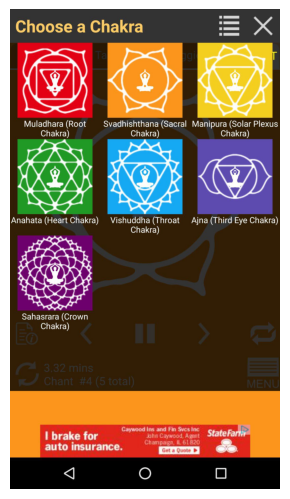

(<Figure size 300x533.333 with 1 Axes>, <Axes: >)

In [41]:
sample_index = 0
sample_n = 30
sample_seed = 42

unmatched_review_sample_df = unmatched_by_all_models_df.sample(
    n=min(sample_n, len(unmatched_by_all_models_df)),
    random_state=sample_seed,
).reset_index(drop=True)

unmatched_expert_sample_path = REVIEW_DIR / "unmatched_expert_review_sample.csv"
unmatched_pair_sample_path = REVIEW_DIR / "unmatched_expert_review_pairs.csv"
unmatched_review_sample_df.to_csv(unmatched_expert_sample_path, index=False)

unmatched_review_pairs_df = (
    unmatched_review_sample_df[["screen_task_id", "expert_comment_id"]]
    .merge(metric_pairs_df, on=["screen_task_id", "expert_comment_id"], how="left")
    [["model_short", "pair_id", "screen_task_id", "expert_comment_id", "llm_comment_id", "relation", "confidence"]]
    .sort_values(["screen_task_id", "expert_comment_id", "model_short", "llm_comment_id"])
)
unmatched_review_pairs_df.to_csv(unmatched_pair_sample_path, index=False)
print(f"Saved sampled expert IDs to {unmatched_expert_sample_path}")
print(f"Saved {len(unmatched_review_pairs_df):,} associated pair IDs to {unmatched_pair_sample_path}")

if not 0 <= sample_index < len(unmatched_review_sample_df):
    raise IndexError(f"sample_index must be between 0 and {len(unmatched_review_sample_df) - 1}")

print(f"Showing unmatched expert comment {sample_index + 1}/{len(unmatched_review_sample_df)}")
display_unmatched_expert_comment_review(unmatched_review_sample_df.iloc[[sample_index]])
show_screen(
    screen_id=unmatched_review_sample_df.iloc[sample_index]["screen_id"],
    bboxes=unmatched_review_sample_df.iloc[sample_index]["expert_bounding_box"],
    labels=["Expert target"],
)


### Qualitative analysis of shared expert-comment omissions

We qualitatively inspected a reproducible random sample of 30 unique expert comments that were not covered by any of the three models. Each comment was assessed against the complete interface screenshot, with the expert-provided bounding box treated as the target region rather than as a crop that excluded surrounding interaction context. This sample therefore characterizes shared blind spots across models; it is not an estimate of model-specific failure rates.

The review showed that an unmatched expert comment does not necessarily constitute a clear model failure. Twelve of the 30 comments described a specific, visually localized concern supported by the target region, including insufficient edge margins, small or tightly spaced controls, weak typographic hierarchy, low-contrast text, and ambiguous icons. These cases provide the strongest evidence of shared omissions. Nine comments were dependent on interaction context or design conventions that could not be resolved from a static screenshot alone. This group included claims about missing Back or Cancel controls, the need to scroll, and insufficient information about an application's purpose. Five comments were broad or subjective (for example, that colours were unappealing, the layout was basic, or the composition lacked balance), making exact semantic recovery unlikely even when a model identified more concrete problems in the same region. The remaining four appeared inconsistent with the visible evidence: two reported spelling or icon-detail defects not present in the target region, one claimed that an icon-rich screen lacked icons, and one characterized a simple heart symbol as overly detailed.

The model outputs also revealed several near misses hidden by the categorical coverage score. For example, models identified weak contrast and grid imbalance where the expert used the broader description of unappealing colours and a basic layout; they identified weak hierarchy in the same navigation drawer where the expert compared heading and menu typography; and they criticized the date picker's low contrast and unclear operation while omitting the expert's specific request for a Cancel action. Conversely, some highly localized concerns, such as edge margins, control size and spacing, and small low-contrast text, were not recovered despite being visually verifiable. Thus, disagreement arose from at least three sources: genuine omission of an expert-identified issue, different but defensible prioritization of another problem in the same target area, and noise or underspecification in the expert reference itself.

These findings qualify the interpretation of expert-comment recall. Treating every unmatched expert statement as a false negative would overstate model unreliability because the expert annotations are not uniformly specific, observable, or correct. At the same time, the repeated omission of concrete accessibility and interaction details shows that fluent critique generation does not guarantee comprehensive expert alignment. Reliability should therefore be reported along two axes: coverage of valid expert concerns and groundedness of the models' additional critiques. A manual audit should code reference validity, visual observability, semantic near misses, and model-specific omissions before unmatched comments are used as evidence of failure.

For the main qualitative analysis, the sampling unit should be the normalized usability issue rather than the raw comment string. Near-duplicate expert comments across screens should be clustered, with one randomly selected instance per cluster, to prevent frequent templates such as missing Back navigation from dominating a small sample. Cluster prevalence should nevertheless be retained and reported separately, or used as a sampling weight, because deduplication changes the estimand from the distribution of comments to the diversity of issue types. The 30-comment intersection sample is appropriate for analyzing shared blind spots. A separate model-stratified audit (for example, 30 unmatched comments per model, deduplicated within issue cluster and annotated for whether the other models covered the issue) is required for comparative claims about which model is more reliable.
